# Analyze avg-GRM ranked and weighted experiment
This notebook mirrors the short PEVmean analysis workflow for the new avg-GRM experiment.

In [56]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print(Path.cwd())

sns.set_theme(style='whitegrid')

c:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\notebooks


In [ ]:

def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'src').exists() and (p / 'outputs').exists():
            return p
    return start

ROOT = find_project_root(Path.cwd().resolve())
print('ROOT directory:', ROOT)

# Change out_dir to whichever output folder you want to analyse.
out_dir = ROOT / 'outputs' / 'avggrm_rank_weight_all_'

# Optional overlays in the ranked-subset plot. Set to None to skip.
pevmean_results_folder     = None
pca_target_results_folder  = None
pca_source_results_folder  = ROOT / 'outputs' / 'pca_source_rank_weight_test4'

# Auto-discover results CSV (handles plain dir or trait sub-directory).
candidate_results = [
    out_dir / 'avggrm_rank_weight_results.csv',
    *sorted(out_dir.glob('*/avggrm_rank_weight_results.csv')),
    *sorted(out_dir.glob('*/*/avggrm_rank_weight_results.csv')),
]
results_path = next((p for p in candidate_results if p.exists()), None)
if results_path is None:
    raise FileNotFoundError(f'No avggrm_rank_weight_results.csv found under {out_dir}. Run the experiment first.')

results = pd.read_csv(results_path)

def _load_optional(folder, filename, label):
    if folder is None:
        return pd.DataFrame()
    d = Path(folder)
    if not d.is_absolute():
        d = (ROOT / d).resolve()
    candidates = [
        d / filename,
        *sorted(d.glob(f'*/{filename}')),
        *sorted(d.glob(f'*/*/{filename}')),
    ]
    path = next((p for p in candidates if p.exists()), None)
    if path is None:
        print(f'Warning: {filename} not found under {d}. Skipping {label}.')
        return pd.DataFrame()
    print(f'Loaded {label}: {path}')
    return pd.read_csv(path)

pevmean_results    = _load_optional(pevmean_results_folder,    'pevmean_ga_results.csv',               'PEVmean')
pca_target_results = _load_optional(pca_target_results_folder, 'pca_target_rank_weight_results.csv',   'PCA-target')
pca_source_results = _load_optional(pca_source_results_folder, 'pca_source_rank_weight_results.csv',   'PCA-source')

print('Loaded:', results_path)
results.head()


ROOT directory: C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis
Loaded PCA-source: C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\pca_source_rank_weight_test4\pca_source_rank_weight_results.csv
Loaded: C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\avggrm_rank_weight_test1\avggrm_rank_weight_results.csv


,analysis,method,weight_scheme,order_seed,weighted_fit_used,n_individuals,corr_eval,mse_adj,avg_grm_obj,target_island,target_island_name,repeat,repeat_seed,trait
0,full_baseline,full_source_unweighted,none,-2,False,3326,0.210720,1.285977,0.003251,0,Nesøy,0,885682700,body_mass
1,ranked_subset,avggrm_topk,none,-1,False,50,0.189367,1.434926,0.041521,0,Nesøy,0,885682700,body_mass
2,ranked_subset,avggrm_topk,none,-1,False,100,0.084565,1.387776,0.030119,0,Nesøy,0,885682700,body_mass
3,ranked_subset,avggrm_topk,none,-1,False,250,0.157565,1.318938,0.019082,0,Nesøy,0,885682700,body_mass
4,ranked_subset,avggrm_topk,none,-1,False,500,0.191430,1.279496,0.013464,0,Nesøy,0,885682700,body_mass


In [58]:

# --- Dataset summary ---
n_tgt = results['target_island'].nunique()
target_info = (
    results[['target_island', 'target_island_name']]
    .drop_duplicates()
    .sort_values('target_island')
    .reset_index(drop=True)
)
ranked_sizes = sorted(results[results['analysis'] == 'ranked_subset']['n_individuals'].unique().tolist())
traits = sorted(results['trait'].unique().tolist())
n_repeats = results['repeat'].nunique()

print(f"Trait(s)          : {', '.join(traits)}")
print(f"Target islands    : {n_tgt}")
for _, row in target_info.iterrows():
    print(f"  {int(row['target_island']):2d}  {row['target_island_name']}")
print(f"Ranked sizes      : {len(ranked_sizes)} values  ({ranked_sizes[0]}–{ranked_sizes[-1]})")
print(f"Repeats           : {n_repeats}")
print(f"PEVmean data      : {'loaded (%d rows)' % len(pevmean_results)    if len(pevmean_results)    else 'not loaded'}")
print(f"PCA-target data   : {'loaded (%d rows)' % len(pca_target_results) if len(pca_target_results) else 'not loaded'}")
print(f"PCA-source data   : {'loaded (%d rows)' % len(pca_source_results) if len(pca_source_results) else 'not loaded'}")

# --- Companion files ---
selected_path = results_path.with_name('avggrm_ranked_selected_individuals.csv')
weights_path  = results_path.with_name('avggrm_weighted_individuals.csv')
summary_path  = results_path.with_name('avggrm_rank_weight_summary.csv')

selected_df = pd.read_csv(selected_path) if selected_path.exists() else pd.DataFrame()
weights_df  = pd.read_csv(weights_path)  if weights_path.exists()  else pd.DataFrame()
summary_df  = pd.read_csv(summary_path)  if summary_path.exists()  else pd.DataFrame()

print(f"\nFile rows:")
print(f"  results  : {len(results)}")
print(f"  selected : {len(selected_df)}")
print(f"  weights  : {len(weights_df)}")
print(f"  summary  : {len(summary_df)}")


Trait(s)          : body_mass
Target islands    : 11
   0  Nesøy
   1  Myken
   2  Træna
   3  Selvær
   4  Gjerøy
   5  Hestmannøy
   6  Indre Kvarøy
   7  Onøy og Lurøy
   8  Lovund
   9  Sleneset
  10  Aldra
Ranked sizes      : 31 values  (50–3353)
Repeats           : 1
PEVmean data      : not loaded
PCA-target data   : not loaded
PCA-source data   : loaded (1712 rows)



File rows:
  results  : 1364
  selected : 200399
  weights  : 172250
  summary  : 302


In [59]:
agg = (
    results.groupby(['analysis', 'method', 'n_individuals'], as_index=False)
    .agg(corr_mean=('corr_eval', 'mean'), corr_sd=('corr_eval', 'std'), mse_mean=('mse_adj', 'mean'))
    .sort_values(['analysis', 'method', 'n_individuals'])
)
agg.head(20)

,analysis,method,n_individuals,corr_mean,corr_sd,mse_mean
0,full_baseline,full_source_unweighted,2367,0.145091,NaN,1.577608
1,full_baseline,full_source_unweighted,2887,0.097967,NaN,1.475748
2,full_baseline,full_source_unweighted,3089,0.309152,NaN,1.495944
3,full_baseline,full_source_unweighted,3153,0.152656,NaN,1.215064
4,full_baseline,full_source_unweighted,3186,0.013472,NaN,1.361462
5,full_baseline,full_source_unweighted,3251,0.218713,NaN,0.894915
6,full_baseline,full_source_unweighted,3272,0.361528,NaN,1.362412
7,full_baseline,full_source_unweighted,3279,0.142343,NaN,0.973620
8,full_baseline,full_source_unweighted,3287,0.345367,NaN,0.897091
9,full_baseline,full_source_unweighted,3326,0.210720,NaN,1.285977


Using configured n_train_sizes for mean plot: [50, 100, 250, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500]


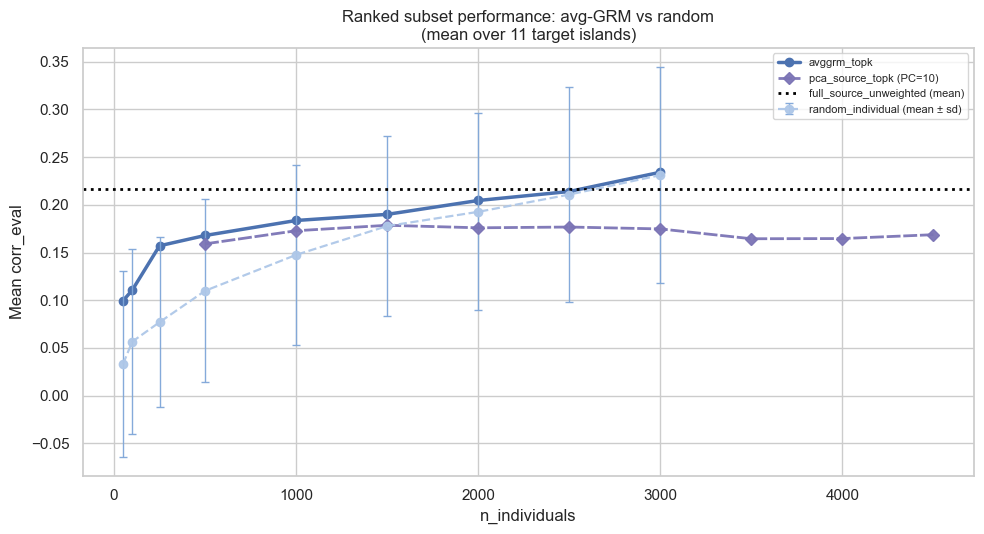

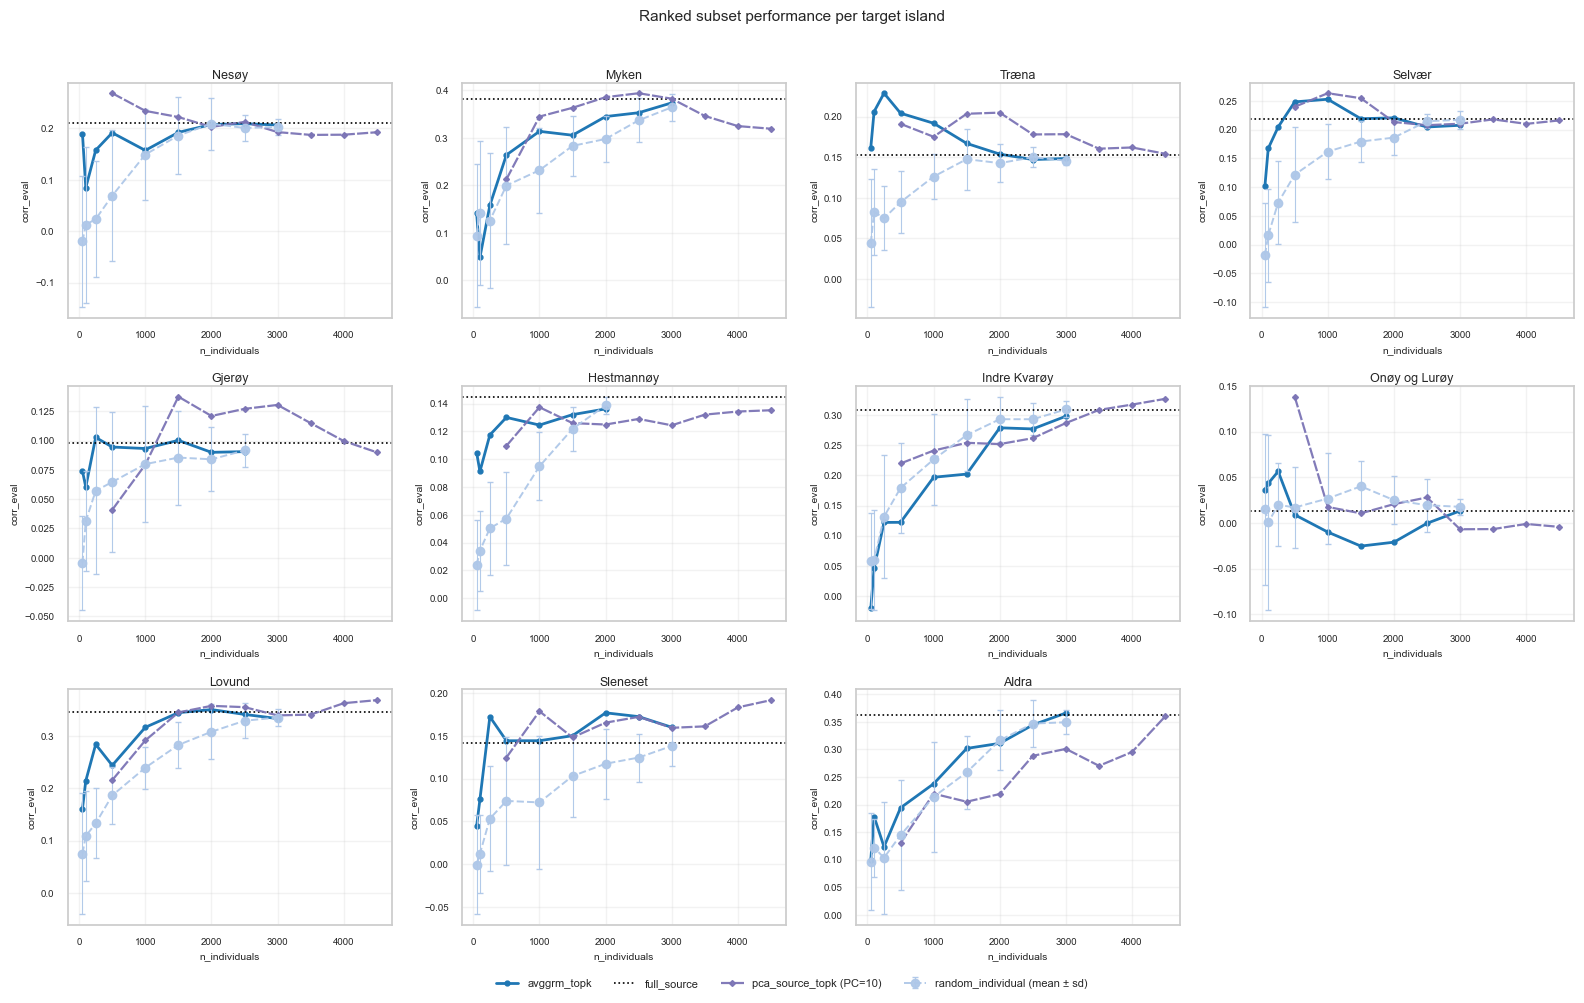

In [60]:
# --- Mean plot (aggregated across all target islands) ---
import json
import math

ranked = results[results['analysis'] == 'ranked_subset'].copy()

# Keep only the original configured n_train_sizes (exclude auto-added points).
cfg_plot_path = ROOT / 'config' / 'avggrm_rank_weight_config.json'
plot_n_values = None
if cfg_plot_path.exists():
    with open(cfg_plot_path, 'r') as f:
        cfg_plot = json.load(f)
    plot_n_values = cfg_plot.get('avggrm_experiment', {}).get('n_train_sizes', None)
    if plot_n_values is not None:
        plot_n_values = sorted(int(x) for x in plot_n_values)
        ranked = ranked[ranked['n_individuals'].astype(int).isin(plot_n_values)].copy()
        print('Using configured n_train_sizes for mean plot:', plot_n_values)
else:
    print('Config not found for filtering n_train_sizes; plotting all available points.')

ranked_mean = (
    ranked.groupby(['method', 'n_individuals'], as_index=False)
    .agg(corr_mean=('corr_eval', 'mean'), corr_sd=('corr_eval', 'std'))
)

full_rows = results[results['method'] == 'full_source_unweighted']
full_corr = full_rows['corr_eval'].mean() if len(full_rows) else np.nan

tgt_label = (
    f'{n_tgt} target islands' if n_tgt > 1
    else str(results['target_island_name'].iloc[0])
)


def _overlay_mean_by_pc(df, method_col, plot_n, filter_n=True):
    """Return mean corr by n_individuals and n_components (if present)."""
    if df.empty or 'method' not in df.columns or method_col not in df['method'].values:
        return pd.DataFrame()

    sub = df[df['method'] == method_col].copy()
    if filter_n and plot_n is not None:
        sub = sub[sub['n_individuals'].astype(int).isin(plot_n)].copy()
    if sub.empty:
        return pd.DataFrame()

    if 'n_components' not in sub.columns:
        sub['n_components'] = -1
    else:
        sub['n_components'] = pd.to_numeric(sub['n_components'], errors='coerce').fillna(-1).astype(int)

    return (
        sub.groupby(['n_components', 'n_individuals'], as_index=False)
        .agg(corr_mean=('corr_eval', 'mean'))
        .sort_values(['n_components', 'n_individuals'])
    )


def _pc_color_map(pcs, cmap_name):
    if not pcs:
        return {}
    if len(pcs) == 1:
        return {pcs[0]: plt.get_cmap(cmap_name)(0.65)}
    cmap = plt.get_cmap(cmap_name)
    vals = np.linspace(0.2, 0.95, len(pcs))
    return {pc: cmap(v) for pc, v in zip(pcs, vals)}


def _plot_overlay_pc_curves(ax, df_means, cmap_name, marker, ls, label_base):
    if df_means.empty:
        return

    ls_cycle = [ls, '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 1))]
    pcs = sorted(df_means['n_components'].unique().tolist())
    pc_colors = _pc_color_map(pcs, cmap_name)

    for i, pc in enumerate(pcs):
        sub_pc = df_means[df_means['n_components'] == pc].sort_values('n_individuals')
        if sub_pc.empty:
            continue

        show_pc = (pc >= 0) and (len(pcs) > 1 or label_base.startswith('pca_'))
        label = f"{label_base} (PC={int(pc)})" if show_pc else f"{label_base} (optional)"

        ax.plot(
            sub_pc['n_individuals'], sub_pc['corr_mean'],
            marker=marker,
            linestyle=ls_cycle[i % len(ls_cycle)],
            linewidth=2.0,
            color=pc_colors.get(pc, '#444444'),
            alpha=0.95,
            label=label,
        )


# Overlay styles for optional methods
_overlays = [
    (pevmean_results,    'pevmean_ga',      'Oranges', 's', '-.',             'pevmean_ga'),
    (pca_target_results, 'pca_target_topk', 'Greens',  '^', (0, (3, 1, 1, 1)), 'pca_target_topk'),
    (pca_source_results, 'pca_source_topk', 'Purples', 'D', (0, (5, 1)),       'pca_source_topk'),
]

plt.figure(figsize=(10, 5.5))
for method, sub in ranked_mean.groupby('method'):
    sub = sub.sort_values('n_individuals')

    if method == 'random_individual':
        yerr = sub['corr_sd'].fillna(0.0).to_numpy()
        plt.errorbar(
            sub['n_individuals'], sub['corr_mean'],
            yerr=yerr,
            fmt='o--',
            linewidth=1.6,
            elinewidth=1.0,
            capsize=3,
            color='#aec7e8',
            ecolor='#7fa6d8',
            alpha=0.95,
            label='random_individual (mean ± sd)',
        )
    else:
        ls = '-' if method == 'avggrm_topk' else '-'
        lw = 2.5 if method == 'avggrm_topk' else 1.6
        plt.plot(sub['n_individuals'], sub['corr_mean'], marker='o', linestyle=ls, linewidth=lw, label=method)

for df, method_col, cmap_name, marker, ls, label in _overlays:
    means = _overlay_mean_by_pc(df, method_col, plot_n_values)
    _plot_overlay_pc_curves(plt.gca(), means, cmap_name, marker, ls, label)

if np.isfinite(full_corr):
    plt.axhline(full_corr, color='black', linestyle=':', linewidth=2,
                label='full_source_unweighted (mean)')

plt.title(f'Ranked subset performance: avg-GRM vs random\n(mean over {tgt_label})')
plt.xlabel('n_individuals')
plt.ylabel('Mean corr_eval')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# --- Per-target-island grid ---
if n_tgt > 1:
    full_per_tgt = (
        results[results['method'] == 'full_source_unweighted']
        .groupby('target_island_name', as_index=False)
        .agg(full_corr=('corr_eval', 'mean'))
    )

    def _per_island_mean(df, method_col):
        if df.empty or 'target_island_name' not in df.columns:
            return pd.DataFrame()
        if 'method' not in df.columns or method_col not in df['method'].values:
            return pd.DataFrame()

        sub = df[df['method'] == method_col].copy()
        if sub.empty:
            return pd.DataFrame()

        if 'n_components' not in sub.columns:
            sub['n_components'] = -1
        else:
            sub['n_components'] = pd.to_numeric(sub['n_components'], errors='coerce').fillna(-1).astype(int)

        return (
            sub.groupby(['target_island_name', 'n_components', 'n_individuals'], as_index=False)
            .agg(corr_mean=('corr_eval', 'mean'))
            .sort_values(['target_island_name', 'n_components', 'n_individuals'])
        )

    pev_per_tgt = _per_island_mean(pevmean_results, 'pevmean_ga')
    pca_target_per_tgt = _per_island_mean(pca_target_results, 'pca_target_topk')
    pca_source_per_tgt = _per_island_mean(pca_source_results, 'pca_source_topk')

    island_order = target_info['target_island_name'].tolist()
    n_panels = len(island_order)
    n_cols_g = min(4, n_panels)
    n_rows_g = int(math.ceil(n_panels / n_cols_g))
    panel_w, panel_h = 4.0, 3.2
    fig, axes = plt.subplots(
        n_rows_g, n_cols_g,
        figsize=(n_cols_g * panel_w, n_rows_g * panel_h),
        squeeze=False,
        sharey=False,
    )

    method_styles = {
        'avggrm_topk': dict(color='#1f77b4', ls='-', lw=2.0, marker='o', ms=3.5),
        'random_individual': dict(color='#aec7e8', ls='--', lw=1.4, marker='o', ms=3),
    }

    overlay_styles = [
        (pev_per_tgt, 'Oranges', '-.', 's', 3, 'pevmean_ga'),
        (pca_target_per_tgt, 'Greens', (0, (3, 1, 1, 1)), '^', 3, 'pca_target_topk'),
        (pca_source_per_tgt, 'Purples', (0, (5, 1)), 'D', 3, 'pca_source_topk'),
    ]

    def _plot_island_overlay(ax, per_tgt_df, island_name, cmap_name, ls, marker, ms, label_base):
        if per_tgt_df.empty:
            return
        ls_cycle = [ls, '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 1))]
        sub_ov = per_tgt_df[per_tgt_df['target_island_name'] == island_name].copy()
        if sub_ov.empty:
            return

        pcs = sorted(sub_ov['n_components'].unique().tolist())
        pc_colors = _pc_color_map(pcs, cmap_name)
        for i, pc in enumerate(pcs):
            csub = sub_ov[sub_ov['n_components'] == pc].sort_values('n_individuals')
            if csub.empty:
                continue
            show_pc = (pc >= 0) and (len(pcs) > 1 or label_base.startswith('pca_'))
            label = f"{label_base} (PC={int(pc)})" if show_pc else label_base
            ax.plot(
                csub['n_individuals'], csub['corr_mean'],
                color=pc_colors.get(pc, '#444444'),
                ls=ls_cycle[i % len(ls_cycle)],
                lw=1.6,
                marker=marker,
                ms=ms,
                alpha=0.95,
                label=label,
            )

    for ax, island_name in zip(axes.flatten(), island_order):
        sub_r = ranked[ranked['target_island_name'] == island_name]
        sub_mean = (
            sub_r.groupby(['method', 'n_individuals'], as_index=False)
            .agg(corr_mean=('corr_eval', 'mean'), corr_sd=('corr_eval', 'std'))
        )
        for meth, style in method_styles.items():
            m_sub = sub_mean[sub_mean['method'] == meth].sort_values('n_individuals')
            if m_sub.empty:
                continue

            if meth == 'random_individual':
                yerr = m_sub['corr_sd'].fillna(0.0).to_numpy()
                ax.errorbar(
                    m_sub['n_individuals'], m_sub['corr_mean'],
                    yerr=yerr,
                    fmt='o--',
                    linewidth=style['lw'],
                    elinewidth=0.8,
                    capsize=2,
                    color=style['color'],
                    ecolor=style['color'],
                    alpha=0.95,
                    label='random_individual (mean ± sd)',
                )
            else:
                ax.plot(m_sub['n_individuals'], m_sub['corr_mean'], label=meth, **style)

        fc_row = full_per_tgt[full_per_tgt['target_island_name'] == island_name]
        if not fc_row.empty:
            ax.axhline(float(fc_row['full_corr'].iloc[0]), color='black', ls=':', lw=1.2, label='full_source')

        for per_tgt_df, cmap_name, ls, marker, ms, label in overlay_styles:
            _plot_island_overlay(ax, per_tgt_df, island_name, cmap_name, ls, marker, ms, label)

        ax.set_title(island_name, fontsize=9, pad=3)
        ax.set_xlabel('n_individuals', fontsize=7.5)
        ax.set_ylabel('corr_eval', fontsize=7.5)
        ax.tick_params(labelsize=7)
        ax.grid(alpha=0.25)

    for ax in axes.flatten()[n_panels:]:
        ax.set_visible(False)

    handles, labels = axes.flatten()[0].get_legend_handles_labels()
    ncol = max(1, min(6, len(handles)))
    fig.legend(handles, labels, loc='lower center', ncol=ncol,
               bbox_to_anchor=(0.5, -0.02), fontsize=8, frameon=False)
    fig.suptitle('Ranked subset performance per target island', y=1.01, fontsize=11)
    fig.tight_layout()
    plt.show()
else:
    print('Only one target island - grid not shown.')

Islands with any negative min avg_grm: 11
Islands with true first-negative markers found: 11


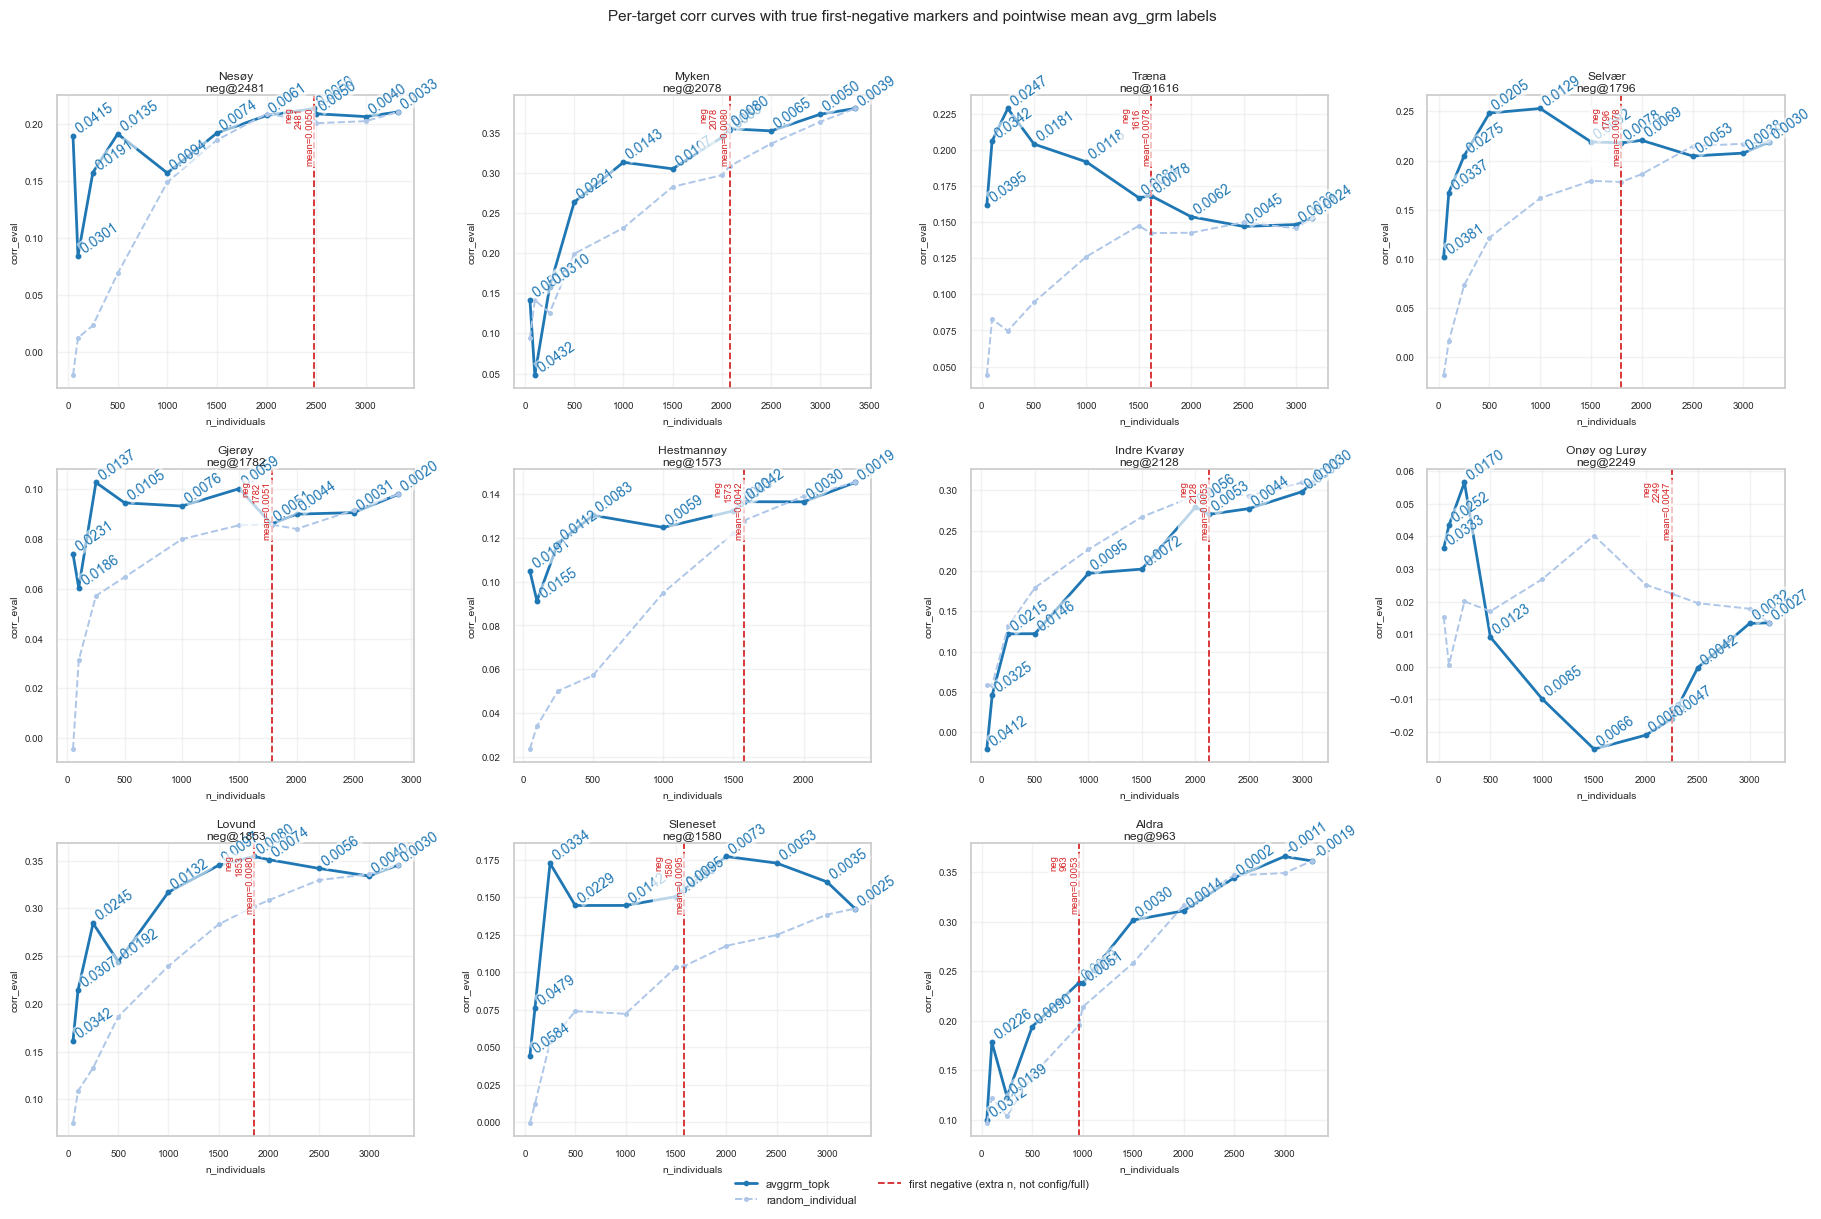

Target island sizes (from locality):
 target_island_name  n_target_individuals
             Myken                    92
             Nesøy                   119
            Lovund                   158
          Sleneset                   166
             Aldra                   173
            Selvær                   194
     Onøy og Lurøy                   259
             Træna                   292
      Indre Kvarøy                   356
            Gjerøy                   558
        Hestmannøy                  1078
Scatter rows: 118 | islands: 11


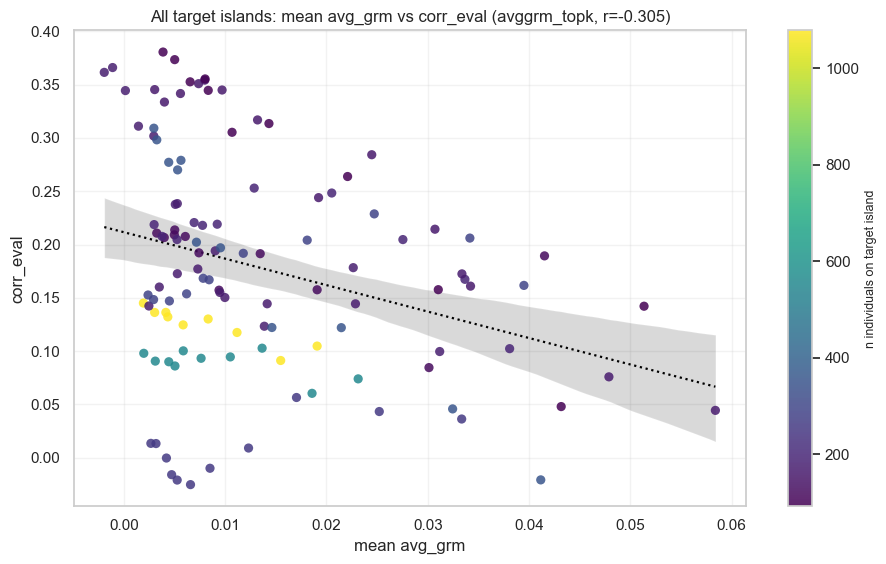

,target_island_name,n_individuals,corr_eval,n_train_size,mean_avg_grm,n_target_individuals
0,Aldra,50,0.099632,50,0.031178,173
1,Aldra,100,0.178318,100,0.022646,173
2,Aldra,250,0.123357,250,0.013869,173
3,Aldra,500,0.194111,500,0.009024,173
4,Aldra,963,0.238409,963,0.005285,173
...,...,...,...,...,...,...
113,Træna,1616,0.168339,1616,0.007835,292
114,Træna,2000,0.153757,2000,0.006199,292
115,Træna,2500,0.147055,2500,0.004502,292
116,Træna,3000,0.148360,3000,0.002941,292


In [61]:

# Grid: top-k/random corr vs n_individuals with true first-negative markers + avg_grm labels
ranked = results[results['analysis'] == 'ranked_subset'].copy()
if ranked.empty:
    raise ValueError('No ranked_subset rows found in results.')
if selected_df.empty:
    raise ValueError('selected_df is empty. Re-run the data-loading cell first.')

import json

# Load configured n_train_sizes so we can identify the extra (auto-added) sizes.
cfg_path = ROOT / 'config' / 'avggrm_rank_weight_config.json'
configured_sizes = set()
if cfg_path.exists():
    with open(cfg_path, 'r') as f:
        cfg = json.load(f)
    configured_sizes = set(int(x) for x in cfg.get('avggrm_experiment', {}).get('n_train_sizes', []))
else:
    print('Warning: config file not found. configured_sizes left empty.')

# Per-island full-source training size(s).
full_source_per_island = (
    results[results['method'] == 'full_source_unweighted']
    .groupby('target_island_name', as_index=False)
    .agg(full_source_n=('n_individuals', 'median'))
)
full_source_per_island['full_source_n'] = full_source_per_island['full_source_n'].astype(int)

# Per-target avg_grm summaries from selected top-k individuals
sel_topk = selected_df[selected_df['method'] == 'avggrm_topk'].copy()
if sel_topk.empty or 'avg_grm' not in sel_topk.columns:
    raise ValueError('selected_df must contain avggrm_topk rows with avg_grm values.')

avggrm_stats = (
    sel_topk.groupby(['target_island_name', 'n_train_size'], as_index=False)
    .agg(
        mean_avg_grm=('avg_grm', 'mean'),
        min_avg_grm=('avg_grm', 'min'),
    )
    .sort_values(['target_island_name', 'n_train_size'])
)
avggrm_stats['n_train_size'] = avggrm_stats['n_train_size'].astype(int)

# First-negative candidates must be outside configured sizes and outside that island's full-source size.
neg_candidates = avggrm_stats.merge(full_source_per_island, on='target_island_name', how='left')
neg_candidates = neg_candidates[
    (~neg_candidates['n_train_size'].isin(configured_sizes))
    & (neg_candidates['n_train_size'] != neg_candidates['full_source_n'])
]
first_neg = (
    neg_candidates
    .sort_values(['target_island_name', 'n_train_size'])
    .groupby('target_island_name', as_index=False)
    .first()
)

n_islands_any_negative = avggrm_stats['target_island_name'].nunique()
print('Islands with any negative min avg_grm:', n_islands_any_negative)
print('Islands with true first-negative markers found:', first_neg['target_island_name'].nunique())

island_order = target_info['target_island_name'].tolist()
n_panels = len(island_order)
n_cols_g = min(4, n_panels)
n_rows_g = int(math.ceil(n_panels / n_cols_g))
fig, axes = plt.subplots(
    n_rows_g, n_cols_g,
    figsize=(n_cols_g * 4.6, n_rows_g * 3.9),
    squeeze=False,
    sharey=False,
)

style_map = {
    'avggrm_topk': dict(color='#1f77b4', ls='-', lw=2.0, marker='o', ms=3.2),
    'random_individual': dict(color='#aec7e8', ls='--', lw=1.4, marker='o', ms=2.6),
}

for ax, island_name in zip(axes.flatten(), island_order):
    # Correlation curves
    sub_r = ranked[ranked['target_island_name'] == island_name].copy()
    sub_mean = (
        sub_r.groupby(['method', 'n_individuals'], as_index=False)
        .agg(corr_mean=('corr_eval', 'mean'))
    )
    for meth, sty in style_map.items():
        m_sub = sub_mean[sub_mean['method'] == meth].sort_values('n_individuals')
        if not m_sub.empty:
            ax.plot(m_sub['n_individuals'], m_sub['corr_mean'], label=meth, **sty)

    # Mean avg_grm values for this island, keyed by n_train_size
    g = avggrm_stats[avggrm_stats['target_island_name'] == island_name].copy()
    g = g.sort_values('n_train_size')
    g_lookup = dict(zip(g['n_train_size'].astype(int), g['mean_avg_grm']))

    # Annotate each avggrm_topk point with the mean avg_grm score.
    topk_curve = sub_mean[sub_mean['method'] == 'avggrm_topk'].sort_values('n_individuals')
    for _, row in topk_curve.iterrows():
        x = int(row['n_individuals'])
        y = float(row['corr_mean'])
        if x in g_lookup:
            ax.text(
                x,
                y,
                f"{g_lookup[x]:.4f}",
                color='#1f77b4',
                fontsize=10,
                rotation=35,
                ha='left',
                va='bottom',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='white', edgecolor='none', alpha=0.55),
            )

    # Red marker at true first-negative point (extra size, not configured and not this island's full source).
    neg_row = first_neg[first_neg['target_island_name'] == island_name]
    if not neg_row.empty:
        neg_start_n = int(neg_row['n_train_size'].iloc[0])
        neg_start_mean = float(neg_row['mean_avg_grm'].iloc[0])
        ax.axvline(neg_start_n, color='#d62728', linestyle='--', linewidth=1.3)

        y_min, y_max = ax.get_ylim()
        y_text = y_max - 0.04 * (y_max - y_min if y_max > y_min else 1.0)
        ax.text(
            neg_start_n,
            y_text,
            f"neg\n{neg_start_n}\nmean={neg_start_mean:.4f}",
            color='#d62728',
            fontsize=6.8,
            rotation=90,
            ha='right',
            va='top',
            bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.7),
        )
        ax.set_title(f'{island_name}\nneg@{neg_start_n}', fontsize=8.7, pad=3)
    else:
        ax.set_title(island_name, fontsize=8.7, pad=3)

    ax.set_xlabel('n_individuals', fontsize=7.5)
    ax.set_ylabel('corr_eval', fontsize=7.5)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.25)

for ax in axes.flatten()[n_panels:]:
    ax.set_visible(False)

legend_handles = [
    plt.Line2D([0], [0], color='#1f77b4', lw=2.0, ls='-', marker='o', ms=3, label='avggrm_topk'),
    plt.Line2D([0], [0], color='#aec7e8', lw=1.4, ls='--', marker='o', ms=2.6, label='random_individual'),
]
if not first_neg.empty:
    legend_handles.append(
        plt.Line2D([0], [0], color='#d62728', lw=1.3, ls='--', label='first negative (extra n, not config/full)')
    )

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=2,
    bbox_to_anchor=(0.5, -0.02),
    fontsize=8,
    frameon=False,
)
fig.suptitle(
    'Per-target corr curves with true first-negative markers and pointwise mean avg_grm labels',
    y=1.01,
    fontsize=11,
)
fig.tight_layout()
plt.show()

# One global scatter: mean avg_grm (x) vs corr_eval (y), colored by target island size.
topk_corr = (
    ranked[ranked['method'] == 'avggrm_topk']
    .groupby(['target_island_name', 'n_individuals'], as_index=False)
    .agg(corr_eval=('corr_eval', 'mean'))
)

scatter_df = topk_corr.merge(
    avggrm_stats[['target_island_name', 'n_train_size', 'mean_avg_grm']],
    left_on=['target_island_name', 'n_individuals'],
    right_on=['target_island_name', 'n_train_size'],
    how='inner',
)
if scatter_df.empty:
    raise ValueError('No rows available for mean avg_grm vs corr_eval scatter.')

# Count individuals per target island from locality array (loaded by provenance cell).
if 'locality' in dir() and isinstance(locality, np.ndarray) and len(locality):
    loc_counts = (
        pd.Series(locality)
        .value_counts()
        .rename('n_target_individuals')
        .rename_axis('target_island')
        .reset_index()
    )
    loc_counts = loc_counts.merge(
        target_info[['target_island', 'target_island_name']], on='target_island', how='inner'
    )
    scatter_df = scatter_df.merge(
        loc_counts[['target_island_name', 'n_target_individuals']],
        on='target_island_name', how='left'
    )
    color_col = 'n_target_individuals'
    color_label = 'n individuals on target island'
    print('Target island sizes (from locality):\n',
          loc_counts[['target_island_name', 'n_target_individuals']].sort_values('n_target_individuals').to_string(index=False))
else:
    scatter_df['n_target_individuals'] = np.nan
    color_col = 'n_individuals'
    color_label = 'n_individuals (training size)'
    print('locality not available – falling back to training size for color.')

r_scatter = scatter_df[['mean_avg_grm', 'corr_eval']].corr(method='pearson').iloc[0, 1]
print('Scatter rows:', len(scatter_df), '| islands:', scatter_df['target_island_name'].nunique())

fig, ax = plt.subplots(figsize=(9.4, 5.8))
sc = ax.scatter(
    scatter_df['mean_avg_grm'],
    scatter_df['corr_eval'],
    c=scatter_df[color_col],
    cmap='viridis',
    alpha=0.85,
    s=44,
    linewidth=0,
    zorder=3,
)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(color_label, fontsize=9)
if len(scatter_df) >= 3 and scatter_df['mean_avg_grm'].nunique() >= 2:
    sns.regplot(
        data=scatter_df,
        x='mean_avg_grm',
        y='corr_eval',
        ax=ax,
        scatter=False,
        color='black',
        line_kws={'linewidth': 1.6, 'linestyle': ':'},
    )
ax.set_title(f'All target islands: mean avg_grm vs corr_eval (avggrm_topk, r={r_scatter:.3f})')
ax.set_xlabel('mean avg_grm')
ax.set_ylabel('corr_eval')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

scatter_df.sort_values(['target_island_name', 'n_individuals']).reset_index(drop=True)


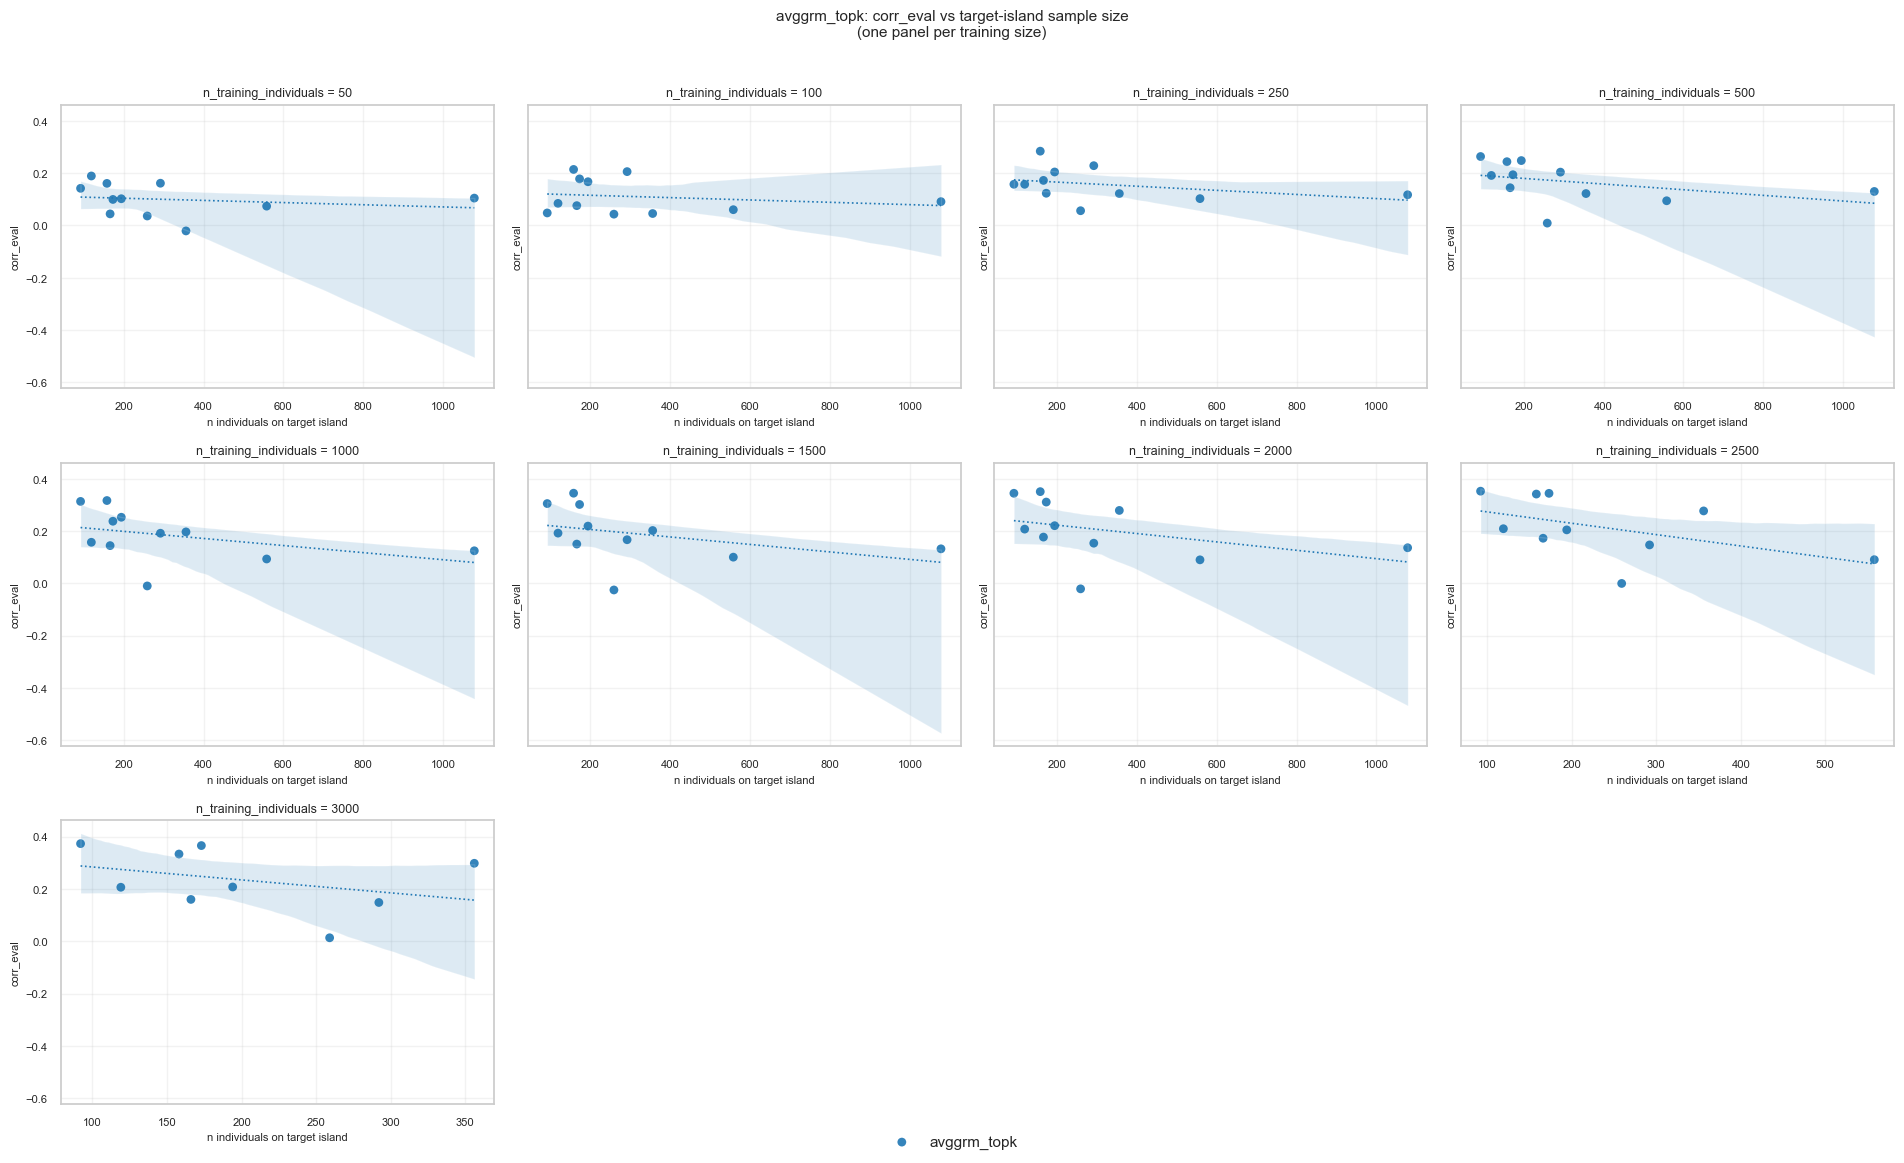

,n_individuals,target_island_name,n_target_individuals,corr_eval
0,50,Aldra,173,0.099632
1,50,Gjerøy,558,0.073985
2,50,Hestmannøy,1078,0.104749
3,50,Indre Kvarøy,356,-0.020781
4,50,Lovund,158,0.160974
...,...,...,...,...
91,3000,Nesøy,119,0.206597
92,3000,Onøy og Lurøy,259,0.013304
93,3000,Selvær,194,0.207635
94,3000,Sleneset,166,0.160131


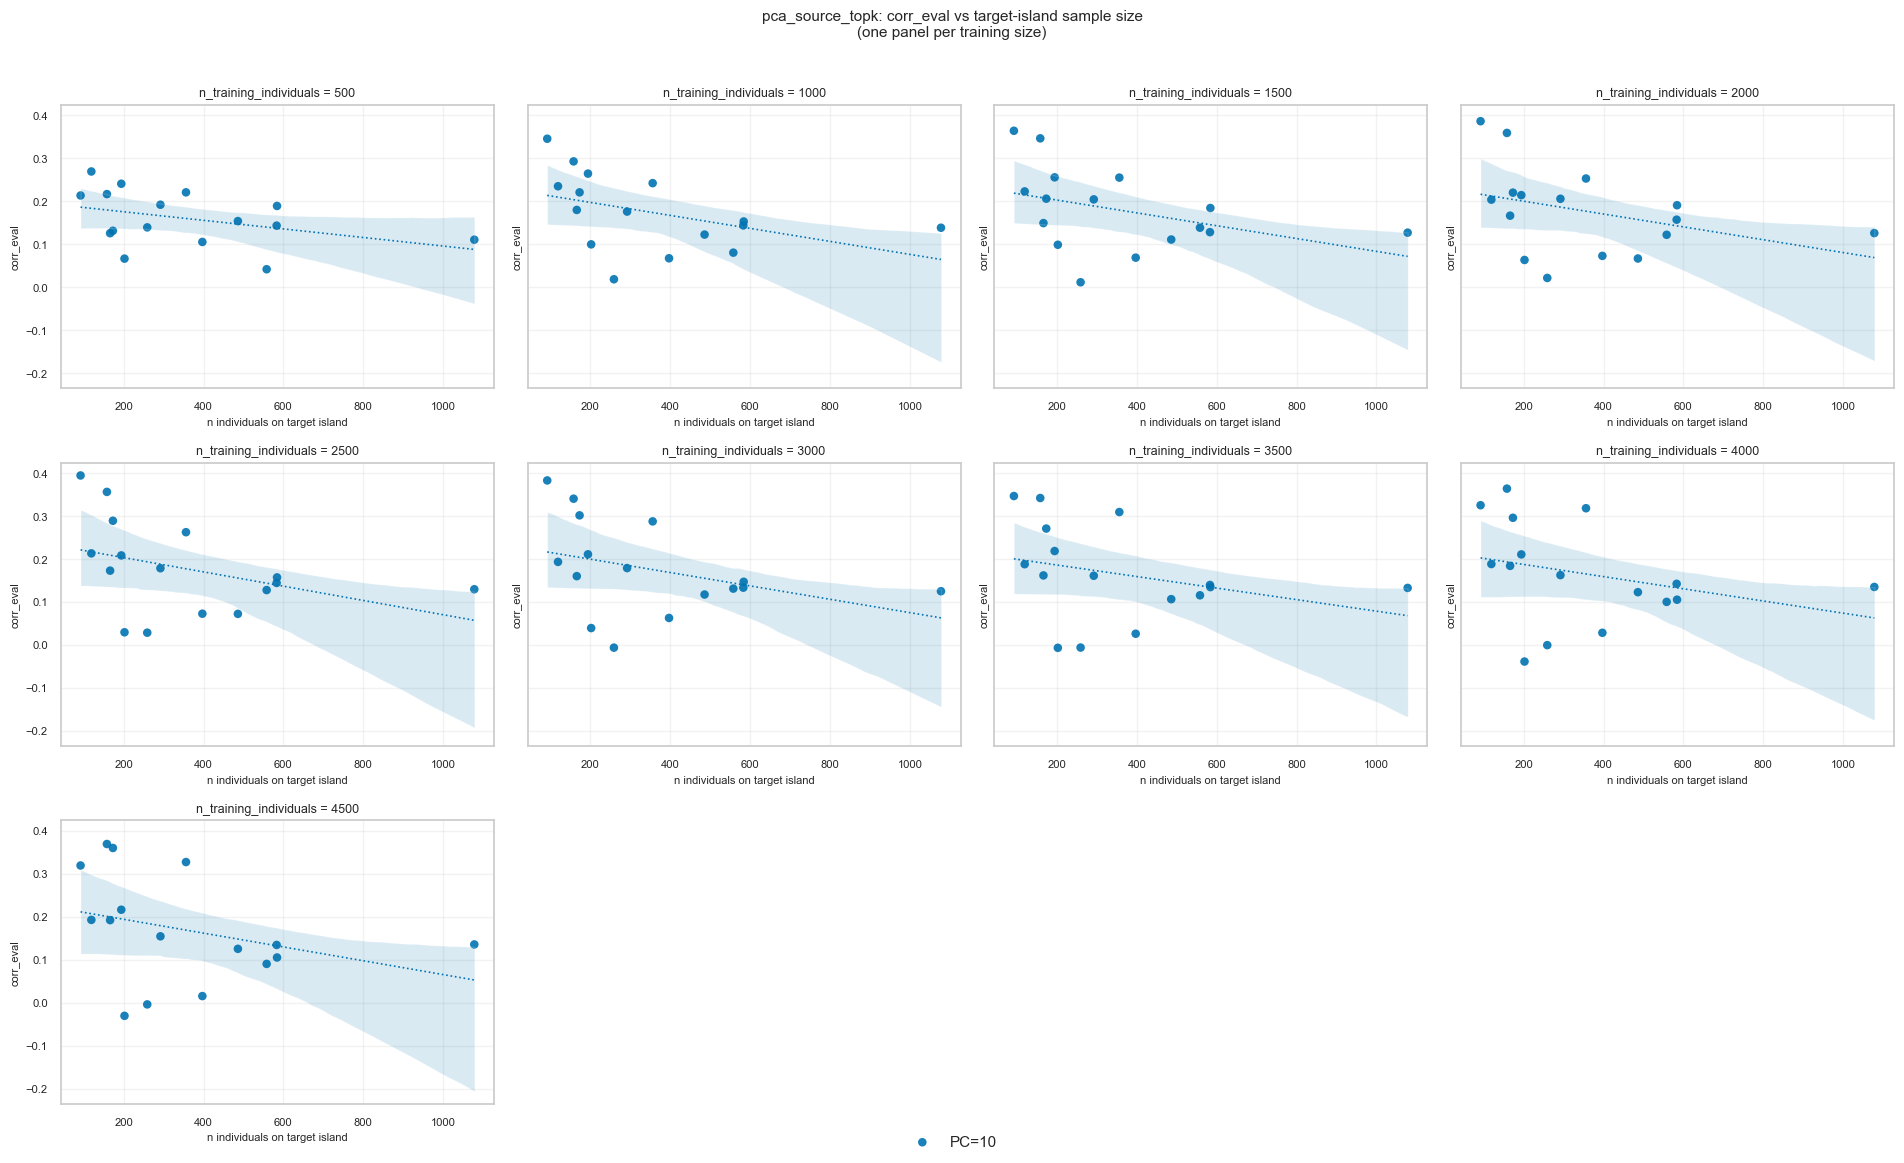

,n_individuals,n_components,target_island_name,n_target_individuals,corr_eval
0,500,10,Aldra,173,0.130408
1,500,10,Gjerøy,558,0.040929
2,500,10,Hestmannøy,1078,0.109642
3,500,10,Indre Kvarøy,356,0.219816
4,500,10,Lovund,158,0.215762
...,...,...,...,...,...
139,4500,10,Southern 2,397,0.015172
140,4500,10,Southern 3,584,0.104956
141,4500,10,Southern 4,486,0.125122
142,4500,10,Southern 5,202,-0.030781


PCA grid PCs: all available


In [62]:
# Grid scatter: corr_eval vs number of individuals on target island
# Figure 1: avggrm_topk only
# Figure 2: pca_source_topk only (filterable by n_components)

import math
import json
import sys

if results.empty:
    raise ValueError('results is empty. Run the loading cells first.')

# User controls
# Set to None to include all configured n_train_sizes, or provide a list like [50, 100, 250].
train_size_filter = None
# Set to None to include all available PCs, or provide a list like [10, 20, 50].
pca_pc_filter = None

# Keep only configured train sizes if config is available
cfg_path = ROOT / 'config' / 'avggrm_rank_weight_config.json'
configured_sizes = None
if cfg_path.exists():
    with open(cfg_path, 'r') as f:
        cfg_sc = json.load(f)
    configured_sizes = cfg_sc.get('avggrm_experiment', {}).get('n_train_sizes', None)
    if configured_sizes is not None:
        configured_sizes = sorted(int(x) for x in configured_sizes)

# Resolve train sizes to plot
if train_size_filter is not None:
    train_sizes_to_use = sorted(int(x) for x in train_size_filter)
else:
    train_sizes_to_use = configured_sizes

# Get number of individuals per target island
if 'locality' in globals() and isinstance(locality, np.ndarray) and len(locality):
    counts_target = (
        pd.Series(locality)
        .value_counts()
        .rename_axis('target_island')
        .reset_index(name='n_target_individuals')
    )
else:
    # Fallback: load locality from config/data once
    ROOT_F = Path.cwd().resolve()
    if not (ROOT_F / 'src').exists():
        ROOT_F = ROOT_F.parent
    if str(ROOT_F) not in sys.path:
        sys.path.insert(0, str(ROOT_F))

    from src.data import load_data

    with open(cfg_path, 'r') as f:
        cfg_sc = json.load(f)

    trait_name = str(results['trait'].iloc[0]) if ('trait' in results.columns and len(results)) else None
    trait_cfg = None
    for t in cfg_sc.get('traits', []):
        if trait_name is None or str(t.get('name')) == trait_name:
            trait_cfg = t
            break
    if trait_cfg is None:
        trait_cfg = cfg_sc.get('traits', [{}])[0]

    paths = dict(cfg_sc['paths'])
    if 'npz' in trait_cfg:
        paths['npz'] = trait_cfg['npz']
    for k, v in list(paths.items()):
        if isinstance(v, str):
            p = Path(v)
            if not p.is_absolute():
                p = (ROOT_F / p).resolve()
            paths[k] = str(p)

    _, _, _, _, locality_loaded, _, _ = load_data(
        paths=paths,
        target_column=trait_cfg.get('target_column', cfg_sc.get('target_column', 'y_adjusted')),
        standardize_features=trait_cfg.get('standardize_features', cfg_sc.get('standardize_features', True)),
        return_locality=True,
        min_count=int(trait_cfg.get('min_count', cfg_sc.get('min_count', 20))),
        return_eval=True,
        eval_target_column=trait_cfg.get('eval_target_column', cfg_sc.get('eval_target_column', 'y_mean')),
    )

    counts_target = (
        pd.Series(locality_loaded)
        .value_counts()
        .rename_axis('target_island')
        .reset_index(name='n_target_individuals')
    )

counts_target['target_island'] = pd.to_numeric(counts_target['target_island'], errors='coerce').astype('Int64')


def _prepare_scatter_df(df, method_name, include_pc=False):
    if df.empty:
        return pd.DataFrame()

    req_cols = ['analysis', 'method', 'target_island', 'target_island_name', 'n_individuals', 'corr_eval']
    missing = [c for c in req_cols if c not in df.columns]
    if missing:
        raise ValueError(f'Missing required columns for scatter plot: {missing}')

    sub = df[(df['analysis'] == 'ranked_subset') & (df['method'] == method_name)].copy()
    if sub.empty:
        return pd.DataFrame()

    sub['target_island'] = pd.to_numeric(sub['target_island'], errors='coerce').astype('Int64')
    sub['n_individuals'] = pd.to_numeric(sub['n_individuals'], errors='coerce')
    sub['corr_eval'] = pd.to_numeric(sub['corr_eval'], errors='coerce')

    if include_pc:
        if 'n_components' not in sub.columns:
            return pd.DataFrame()
        sub['n_components'] = pd.to_numeric(sub['n_components'], errors='coerce')
        sub = sub.dropna(subset=['n_components'])
        sub['n_components'] = sub['n_components'].astype(int)
        if pca_pc_filter is not None:
            pcs = set(int(x) for x in pca_pc_filter)
            sub = sub[sub['n_components'].isin(pcs)].copy()

    sub = sub.dropna(subset=['target_island', 'n_individuals', 'corr_eval']).copy()
    sub['n_individuals'] = sub['n_individuals'].astype(int)

    if train_sizes_to_use is not None:
        sub = sub[sub['n_individuals'].isin(train_sizes_to_use)].copy()

    if sub.empty:
        return pd.DataFrame()

    sub = sub.merge(counts_target, on='target_island', how='left')
    sub = sub.dropna(subset=['n_target_individuals']).copy()
    sub['n_target_individuals'] = sub['n_target_individuals'].astype(int)

    return sub


def _plot_grid(scatter_df, title, include_pc=False):
    if scatter_df.empty:
        print(f'No rows to plot for: {title}')
        return

    if include_pc:
        grouped = (
            scatter_df.groupby(
                ['n_individuals', 'n_components', 'target_island_name', 'n_target_individuals'],
                as_index=False,
            )
            .agg(corr_eval=('corr_eval', 'mean'))
            .sort_values(['n_individuals', 'n_components', 'target_island_name'])
        )
    else:
        grouped = (
            scatter_df.groupby(['n_individuals', 'target_island_name', 'n_target_individuals'], as_index=False)
            .agg(corr_eval=('corr_eval', 'mean'))
            .sort_values(['n_individuals', 'target_island_name'])
        )

    sizes = sorted(grouped['n_individuals'].unique().tolist())
    n_panels = len(sizes)
    n_cols = min(4, n_panels)
    n_rows = int(math.ceil(n_panels / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(n_cols * 4.8, n_rows * 3.8),
        squeeze=False,
        sharey=True,
    )

    if include_pc:
        pcs = sorted(grouped['n_components'].unique().tolist())
        colors = sns.color_palette('colorblind', n_colors=max(1, len(pcs)))
        pc_color = {pc: colors[i] for i, pc in enumerate(pcs)}

    for ax, n_train in zip(axes.flatten(), sizes):
        sub = grouped[grouped['n_individuals'] == n_train].copy()
        if sub.empty:
            ax.set_visible(False)
            continue

        if include_pc:
            for pc in pcs:
                psub = sub[sub['n_components'] == pc].copy()
                if psub.empty:
                    continue
                color = pc_color[pc]
                ax.scatter(
                    psub['n_target_individuals'],
                    psub['corr_eval'],
                    s=38,
                    alpha=0.9,
                    color=color,
                    edgecolors='none',
                    label=f'PC={pc}',
                )
                if len(psub) >= 3 and psub['n_target_individuals'].nunique() >= 2:
                    sns.regplot(
                        data=psub,
                        x='n_target_individuals',
                        y='corr_eval',
                        ax=ax,
                        scatter=False,
                        color=color,
                        line_kws={'linewidth': 1.2, 'linestyle': ':'},
                    )
        else:
            ax.scatter(
                sub['n_target_individuals'],
                sub['corr_eval'],
                s=40,
                alpha=0.9,
                color='#1f77b4',
                edgecolors='none',
                label='avggrm_topk',
            )
            if len(sub) >= 3 and sub['n_target_individuals'].nunique() >= 2:
                sns.regplot(
                    data=sub,
                    x='n_target_individuals',
                    y='corr_eval',
                    ax=ax,
                    scatter=False,
                    color='#1f77b4',
                    line_kws={'linewidth': 1.2, 'linestyle': ':'},
                )

        ax.set_title(f'n_training_individuals = {n_train}', fontsize=9)
        ax.set_xlabel('n individuals on target island', fontsize=8)
        ax.set_ylabel('corr_eval', fontsize=8)
        ax.tick_params(labelsize=8)
        ax.grid(alpha=0.25)

    for ax in axes.flatten()[n_panels:]:
        ax.set_visible(False)

    for ax in axes.flatten():
        if ax.get_visible():
            handles, labels = ax.get_legend_handles_labels()
            if handles:
                fig.legend(handles, labels, loc='lower center', ncol=min(6, len(handles)), frameon=False)
            break

    fig.suptitle(title, y=1.01, fontsize=11)
    fig.tight_layout()
    plt.show()

    display(grouped)


# Figure 1: avggrm top-k only
avggrm_scatter = _prepare_scatter_df(results, method_name='avggrm_topk', include_pc=False)
_plot_grid(
    avggrm_scatter,
    title='avggrm_topk: corr_eval vs target-island sample size\n(one panel per training size)',
    include_pc=False,
)

# Figure 2: PCA-source top-k only (with PC filter)
pca_scatter = _prepare_scatter_df(pca_source_results, method_name='pca_source_topk', include_pc=True)
_plot_grid(
    pca_scatter,
    title='pca_source_topk: corr_eval vs target-island sample size\n(one panel per training size)',
    include_pc=True,
)

if pca_pc_filter is None:
    print('PCA grid PCs: all available')
else:
    print('PCA grid PCs:', sorted(int(x) for x in pca_pc_filter))

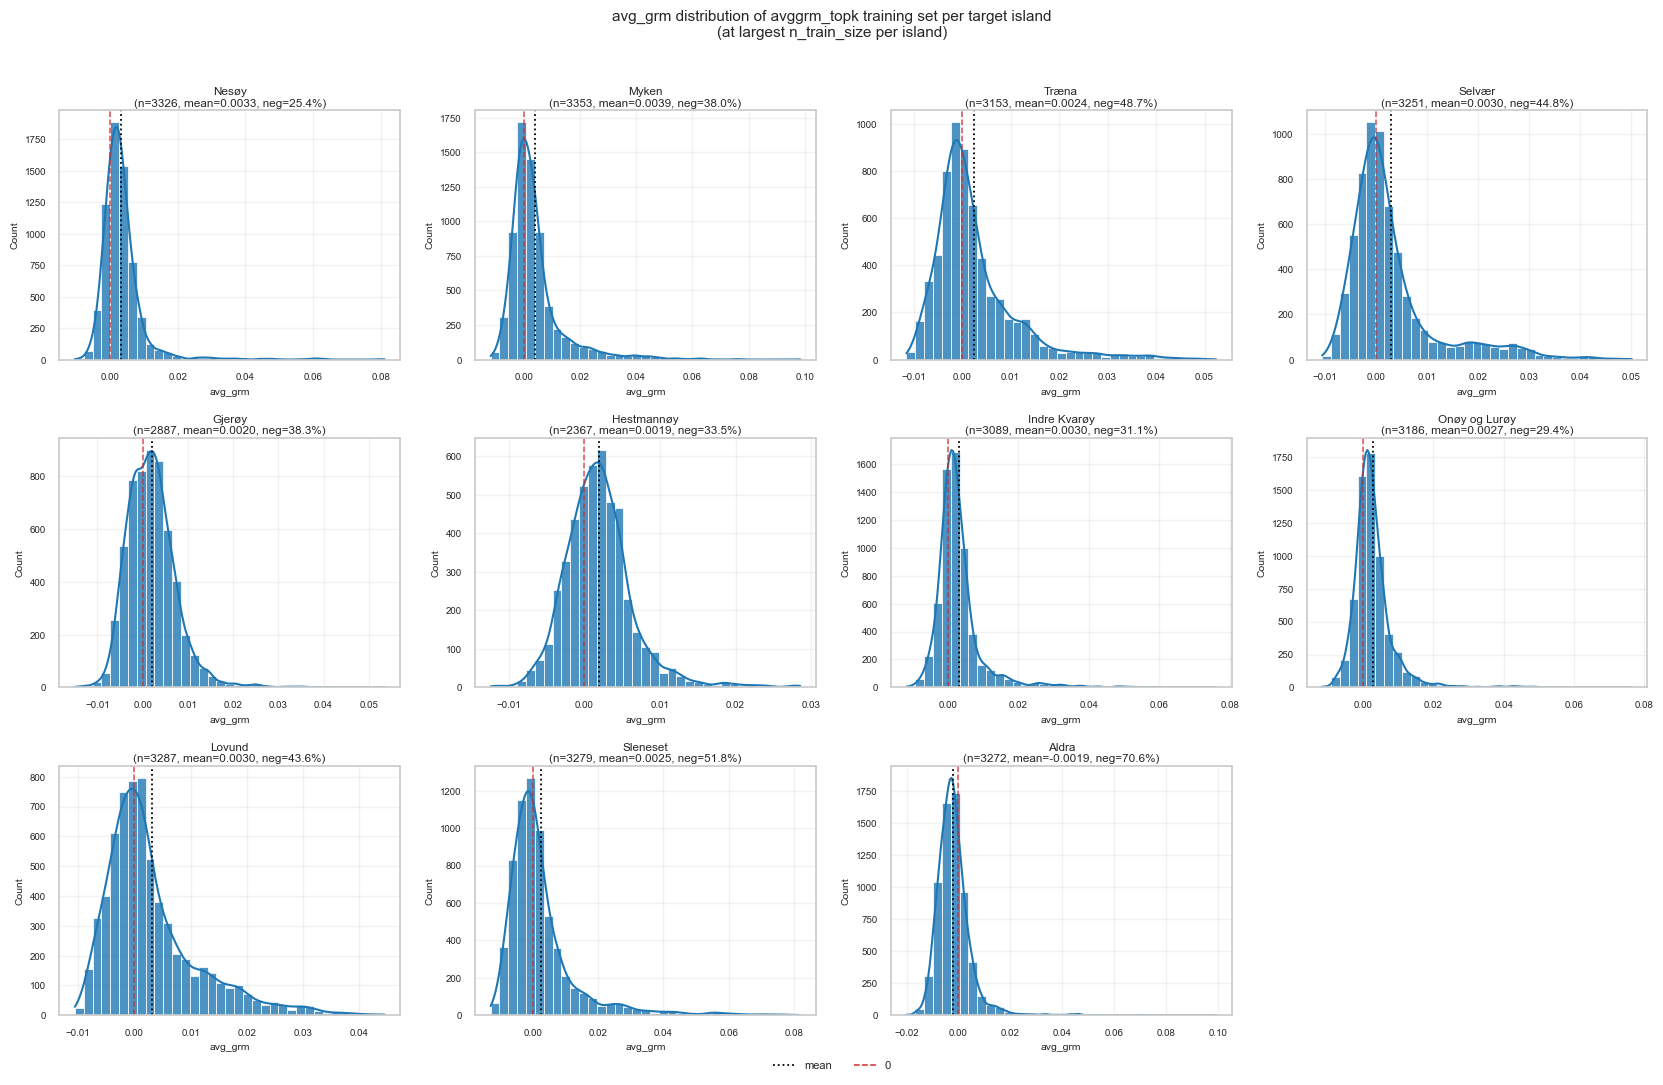

In [63]:

# Grid: avg_grm distribution of avggrm_topk training set, one histogram panel per target island.
# Uses the largest n_train_size for each island to approximate the full-source distribution.
sel_topk_dist = selected_df[selected_df['method'] == 'avggrm_topk'].copy()
if sel_topk_dist.empty or 'avg_grm' not in sel_topk_dist.columns:
    raise ValueError('selected_df must contain avggrm_topk rows with avg_grm values.')

island_order_hist = target_info['target_island_name'].tolist()
n_panels_h = len(island_order_hist)
n_cols_h = min(4, n_panels_h)
n_rows_h = int(math.ceil(n_panels_h / n_cols_h))

fig, axes = plt.subplots(
    n_rows_h, n_cols_h,
    figsize=(n_cols_h * 4.2, n_rows_h * 3.5),
    squeeze=False,
)

for ax, island_name in zip(axes.flatten(), island_order_hist):
    sub = sel_topk_dist[sel_topk_dist['target_island_name'] == island_name].copy()
    if sub.empty:
        ax.set_visible(False)
        continue

    max_n = int(sub['n_train_size'].max())
    sub_max = sub[sub['n_train_size'] == max_n][['avg_grm']].dropna()

    sns.histplot(
        sub_max['avg_grm'],
        bins=35,
        kde=True,
        ax=ax,
        color='#1f77b4',
        edgecolor='white',
        alpha=0.8,
    )

    mean_val = float(sub_max['avg_grm'].mean())
    ax.axvline(mean_val, color='black', linestyle=':', linewidth=1.3)
    ax.axvline(0.0, color='#d62728', linestyle='--', linewidth=1.1, alpha=0.8)

    n_neg = int((sub_max['avg_grm'] < 0).sum())
    pct_neg = 100.0 * n_neg / len(sub_max) if len(sub_max) else 0.0

    ax.set_title(
        f'{island_name}\n(n={max_n}, mean={mean_val:.4f}, neg={pct_neg:.1f}%)',
        fontsize=8.5, pad=3,
    )
    ax.set_xlabel('avg_grm', fontsize=7.5)
    ax.set_ylabel('Count', fontsize=7.5)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.25)

for ax in axes.flatten()[n_panels_h:]:
    ax.set_visible(False)

# Shared legend
legend_handles_h = [
    plt.Line2D([0], [0], color='black', lw=1.3, ls=':', label='mean'),
    plt.Line2D([0], [0], color='#d62728', lw=1.1, ls='--', label='0'),
]
fig.legend(
    handles=legend_handles_h,
    loc='lower center',
    ncol=2,
    bbox_to_anchor=(0.5, -0.01),
    fontsize=8,
    frameon=False,
)
fig.suptitle(
    'avg_grm distribution of avggrm_topk training set per target island\n(at largest n_train_size per island)',
    y=1.01,
    fontsize=11,
)
fig.tight_layout()
plt.show()


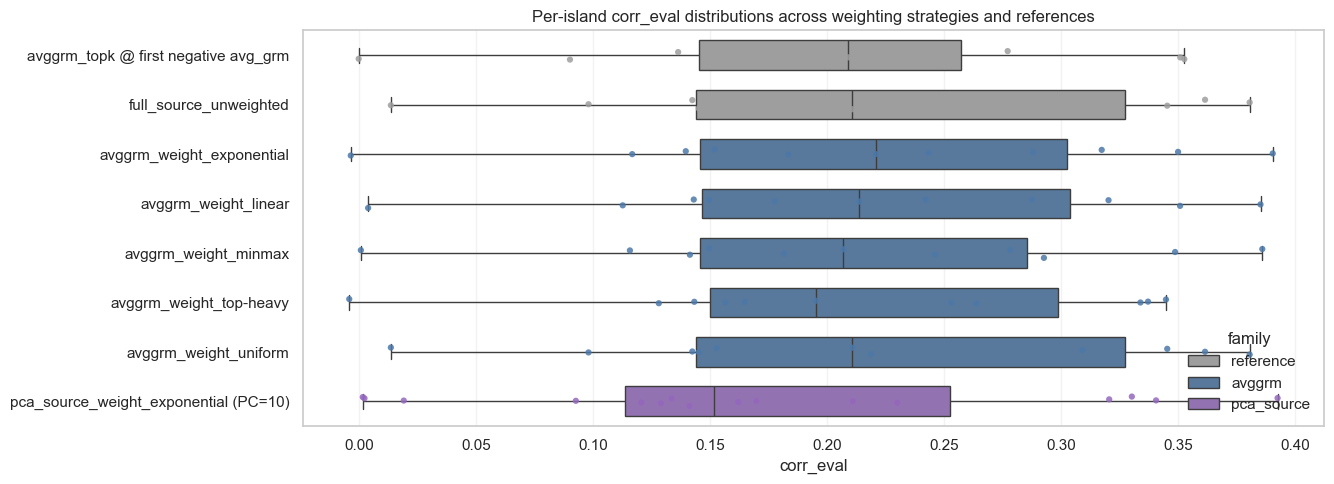

,family,condition,n,mean,median,std,q25,q75,min,max
0,avggrm,avggrm_weight_exponential,11,0.217983,0.22074,0.1156,0.1457,0.3027,-0.003669,0.390463
1,avggrm,avggrm_weight_linear,11,0.216936,0.21371,0.1142,0.1463,0.3039,0.003747,0.385235
2,avggrm,avggrm_weight_uniform,11,0.216146,0.21072,0.1196,0.1437,0.3273,0.013472,0.380595
3,reference,full_source_unweighted,11,0.216146,0.21072,0.1196,0.1437,0.3273,0.013472,0.380595
4,reference,avggrm_topk @ first negative avg_grm,11,0.200452,0.2091,0.1063,0.1450,0.2574,-0.000286,0.352664
5,avggrm,avggrm_weight_minmax,11,0.213388,0.206956,0.1117,0.1454,0.2854,0.000646,0.386003
6,avggrm,avggrm_weight_top-heavy,11,0.210542,0.195128,0.1080,0.1499,0.2988,-0.004321,0.344825
7,pca_source,pca_source_weight_exponential (PC=10),16,0.174735,0.151555,0.1221,0.1136,0.2526,0.001464,0.392538


In [64]:

# Boxplots of per-island correlation across weighting strategies and selection references
if results.empty:
    raise ValueError('results is empty. Run the loading cells first.')
if selected_df.empty:
    raise ValueError('selected_df is empty. Run the loading cells first.')

# Reference 1: full training set (full_source_unweighted)
full_island = (
    results[results['method'] == 'full_source_unweighted']
    .groupby('target_island_name', as_index=False)
    .agg(corr_eval=('corr_eval', 'mean'))
)
full_island['condition'] = 'full_source_unweighted'
full_island['family'] = 'reference'

# Reference 2: correlation at the exact n_train_size where negative avg_grm starts
sel_topk = selected_df[selected_df['method'] == 'avggrm_topk'].copy()
if sel_topk.empty or 'avg_grm' not in sel_topk.columns:
    raise ValueError("selected_df must contain 'avggrm_topk' rows and an 'avg_grm' column.")

neg_start = (
    sel_topk.groupby(['target_island_name', 'n_train_size'], as_index=False)
    .agg(min_avg_grm=('avg_grm', 'min'))
    .sort_values(['target_island_name', 'n_train_size'])
)
neg_start = neg_start[neg_start['min_avg_grm'] < 0]
neg_start = (
    neg_start.groupby('target_island_name', as_index=False)
    .first()[['target_island_name', 'n_train_size']]
)
neg_start['neg_start_n'] = neg_start['n_train_size'].astype(int)
neg_start = neg_start.drop(columns=['n_train_size'])

topk_curve = (
    results[results['method'] == 'avggrm_topk']
    .groupby(['target_island_name', 'n_individuals'], as_index=False)
    .agg(corr_eval=('corr_eval', 'mean'))
)
topk_curve['n_individuals'] = topk_curve['n_individuals'].astype(int)

neg_corr_merge = neg_start.merge(
    topk_curve,
    left_on=['target_island_name', 'neg_start_n'],
    right_on=['target_island_name', 'n_individuals'],
    how='left',
)
missing_exact = neg_corr_merge[neg_corr_merge['corr_eval'].isna()].copy()
if not missing_exact.empty:
    print('Warning: Exact negative-start n not found in topk curve for these islands:')
    print(missing_exact[['target_island_name', 'neg_start_n']].to_string(index=False))

neg_corr_island = neg_corr_merge[['target_island_name', 'corr_eval']].dropna().copy()
neg_corr_island['condition'] = 'avggrm_topk @ first negative avg_grm'
neg_corr_island['family'] = 'reference'
if neg_corr_island.empty:
    print('Warning: No exact matches for negative-start n were found.')


def _format_condition_label(method, n_components):
    label = str(method)
    if n_components is not None and int(n_components) >= 0:
        label = f'{label} (PC={int(n_components)})'
    return label


def _collect_weighted_conditions(df, family_label):
    if df.empty or 'analysis' not in df.columns or 'method' not in df.columns:
        return pd.DataFrame(columns=['target_island_name', 'corr_eval', 'condition', 'family'])

    weighted = df[df['analysis'] == 'weighted_full'].copy()
    if weighted.empty:
        return pd.DataFrame(columns=['target_island_name', 'corr_eval', 'condition', 'family'])

    if 'n_components' not in weighted.columns:
        weighted['n_components'] = -1
    else:
        weighted['n_components'] = pd.to_numeric(weighted['n_components'], errors='coerce').fillna(-1).astype(int)

    grouped = (
        weighted.groupby(['target_island_name', 'method', 'n_components'], as_index=False)
        .agg(corr_eval=('corr_eval', 'mean'))
    )
    grouped['condition'] = [
        _format_condition_label(method, n_components)
        for method, n_components in zip(grouped['method'], grouped['n_components'])
    ]
    grouped['family'] = family_label
    return grouped[['target_island_name', 'corr_eval', 'condition', 'family']]


avggrm_weight_island = _collect_weighted_conditions(results, 'avggrm')
pca_target_weight_island = _collect_weighted_conditions(pca_target_results, 'pca_target')
pca_source_weight_island = _collect_weighted_conditions(pca_source_results, 'pca_source')

box_df = pd.concat(
    [
        full_island,
        neg_corr_island,
        avggrm_weight_island,
        pca_target_weight_island,
        pca_source_weight_island,
    ],
    ignore_index=True,
)
box_df = box_df.dropna(subset=['corr_eval']).copy()
if box_df.empty:
    raise ValueError('No rows available for weighting comparison figure.')

family_priority = {
    'reference': 0,
    'avggrm': 1,
    'pca_target': 2,
    'pca_source': 3,
}
condition_meta = box_df[['condition', 'family']].drop_duplicates().copy()
condition_meta['family_rank'] = condition_meta['family'].map(family_priority).fillna(99)
condition_order = (
    condition_meta
    .sort_values(['family_rank', 'condition'])['condition']
    .tolist()
)

palette = {
    'reference': '#9e9e9e',
    'avggrm': '#4c78a8',
    'pca_target': '#2ca02c',
    'pca_source': '#9467bd',
}

fig_h = max(5.0, 0.42 * len(condition_order) + 1.6)
fig, ax = plt.subplots(figsize=(13.5, fig_h))

sns.boxplot(
    data=box_df,
    y='condition',
    x='corr_eval',
    order=condition_order,
    hue='family',
    dodge=False,
    palette=palette,
    width=0.6,
    fliersize=0,
    ax=ax,
)

sns.stripplot(
    data=box_df,
    y='condition',
    x='corr_eval',
    order=condition_order,
    hue='family',
    dodge=False,
    palette=palette,
    size=4.5,
    alpha=0.85,
    linewidth=0,
    ax=ax,
)

handles, labels = ax.get_legend_handles_labels()
seen = set()
legend_handles = []
legend_labels = []
for handle, label in zip(handles, labels):
    if label in palette and label not in seen:
        seen.add(label)
        legend_handles.append(handle)
        legend_labels.append(label)
if legend_handles:
    ax.legend(legend_handles, legend_labels, title='family', frameon=False, loc='lower right')

ax.set_title('Per-island corr_eval distributions across weighting strategies and references', fontsize=12)
ax.set_xlabel('corr_eval')
ax.set_ylabel('')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

# Summary table: one row per condition, sorted by median corr_eval descending
condition_summary = (
    box_df.groupby(['family', 'condition'])['corr_eval']
    .agg(
        n='count',
        mean='mean',
        median='median',
        std='std',
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        min='min',
        max='max',
    )
    .reset_index()
    .sort_values('median', ascending=False)
    .reset_index(drop=True)
)
condition_summary[['mean', 'median', 'std', 'q25', 'q75', 'min', 'max']] = (
    condition_summary[['mean', 'median', 'std', 'q25', 'q75', 'min', 'max']].round(4)
)
condition_summary


In [65]:
# Compact CSV for the per-target corr_eval figure (avggrm_topk vs random_individual)
figure_summary = (
    results[
        (results['analysis'] == 'ranked_subset')
        & (results['method'].isin(['avggrm_topk', 'random_individual']))
    ]
    .groupby(['target_island', 'target_island_name', 'method', 'n_individuals'], as_index=False)
    .agg(corr_eval_mean=('corr_eval', 'mean'))
    .sort_values(['target_island', 'method', 'n_individuals'])
)

figure_summary_path = results_path.with_name('avggrm_ranked_target_summary.csv')
figure_summary.to_csv(figure_summary_path, index=False)

print('Saved:', figure_summary_path)
figure_summary.head(20)

Saved: C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\avggrm_rank_weight_test1\avggrm_ranked_target_summary.csv


,target_island,target_island_name,method,n_individuals,corr_eval_mean
0,0,Nesøy,avggrm_topk,50,0.189367
1,0,Nesøy,avggrm_topk,100,0.084565
2,0,Nesøy,avggrm_topk,250,0.157565
3,0,Nesøy,avggrm_topk,500,0.191430
4,0,Nesøy,avggrm_topk,1000,0.157186
5,0,Nesøy,avggrm_topk,1500,0.192227
6,0,Nesøy,avggrm_topk,2000,0.207583
7,0,Nesøy,avggrm_topk,2481,0.213702
8,0,Nesøy,avggrm_topk,2500,0.209100
9,0,Nesøy,avggrm_topk,3000,0.206597


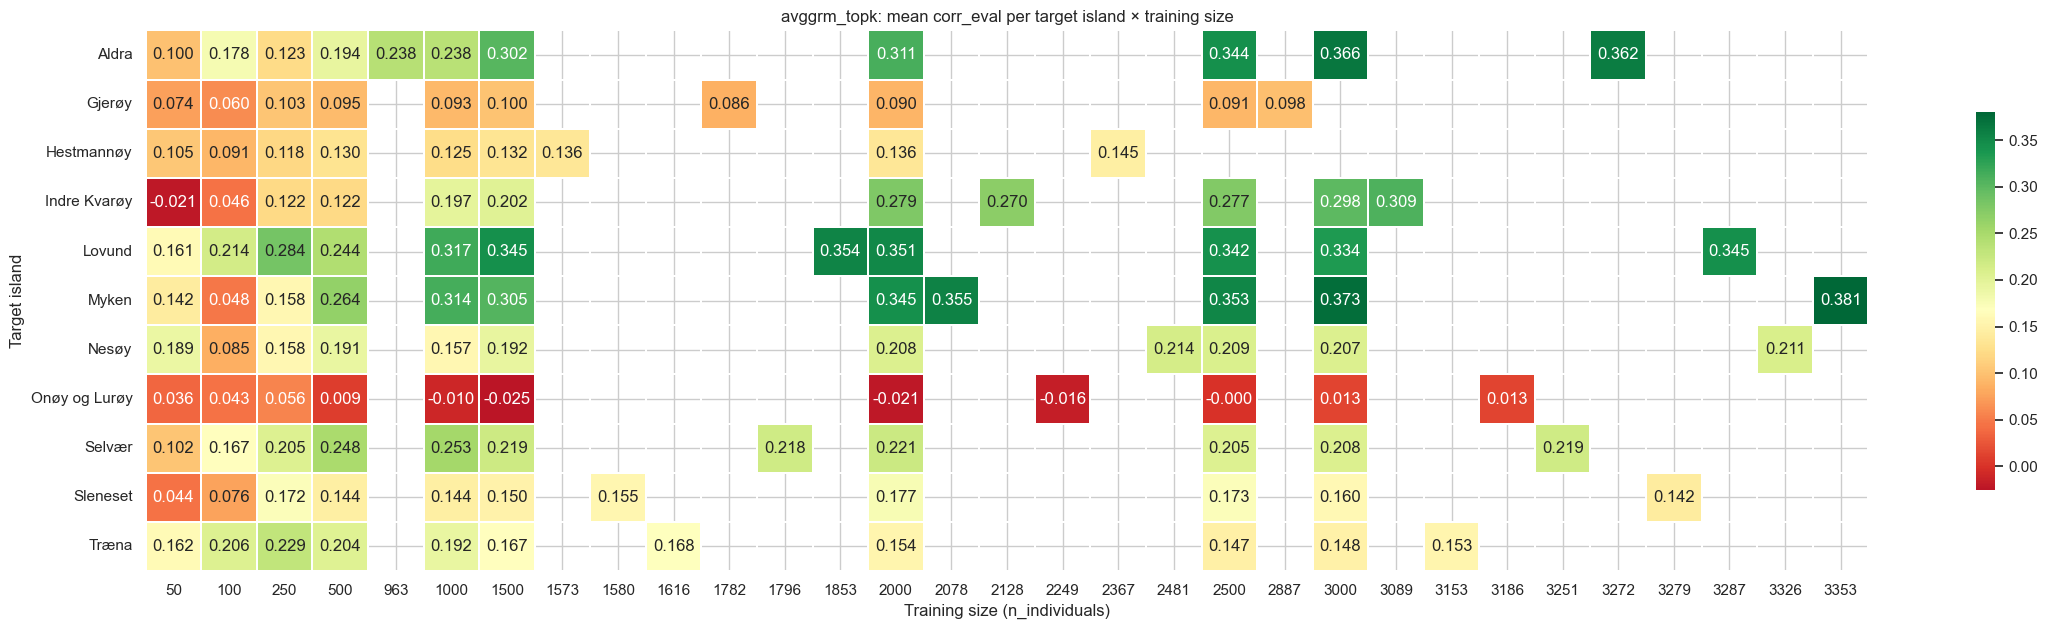

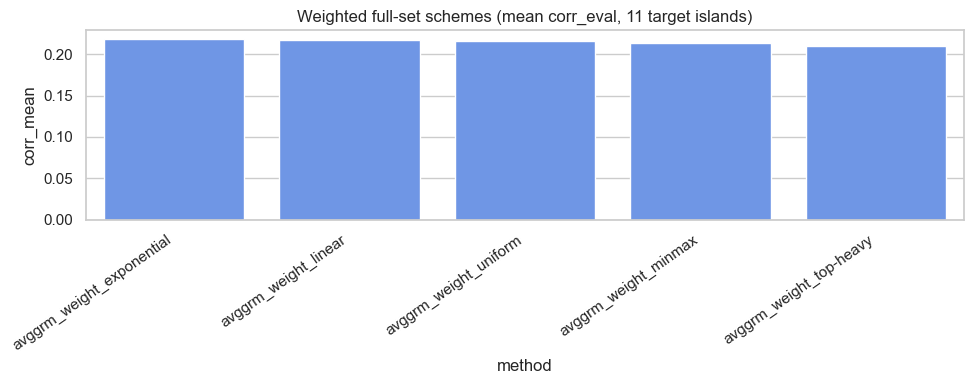

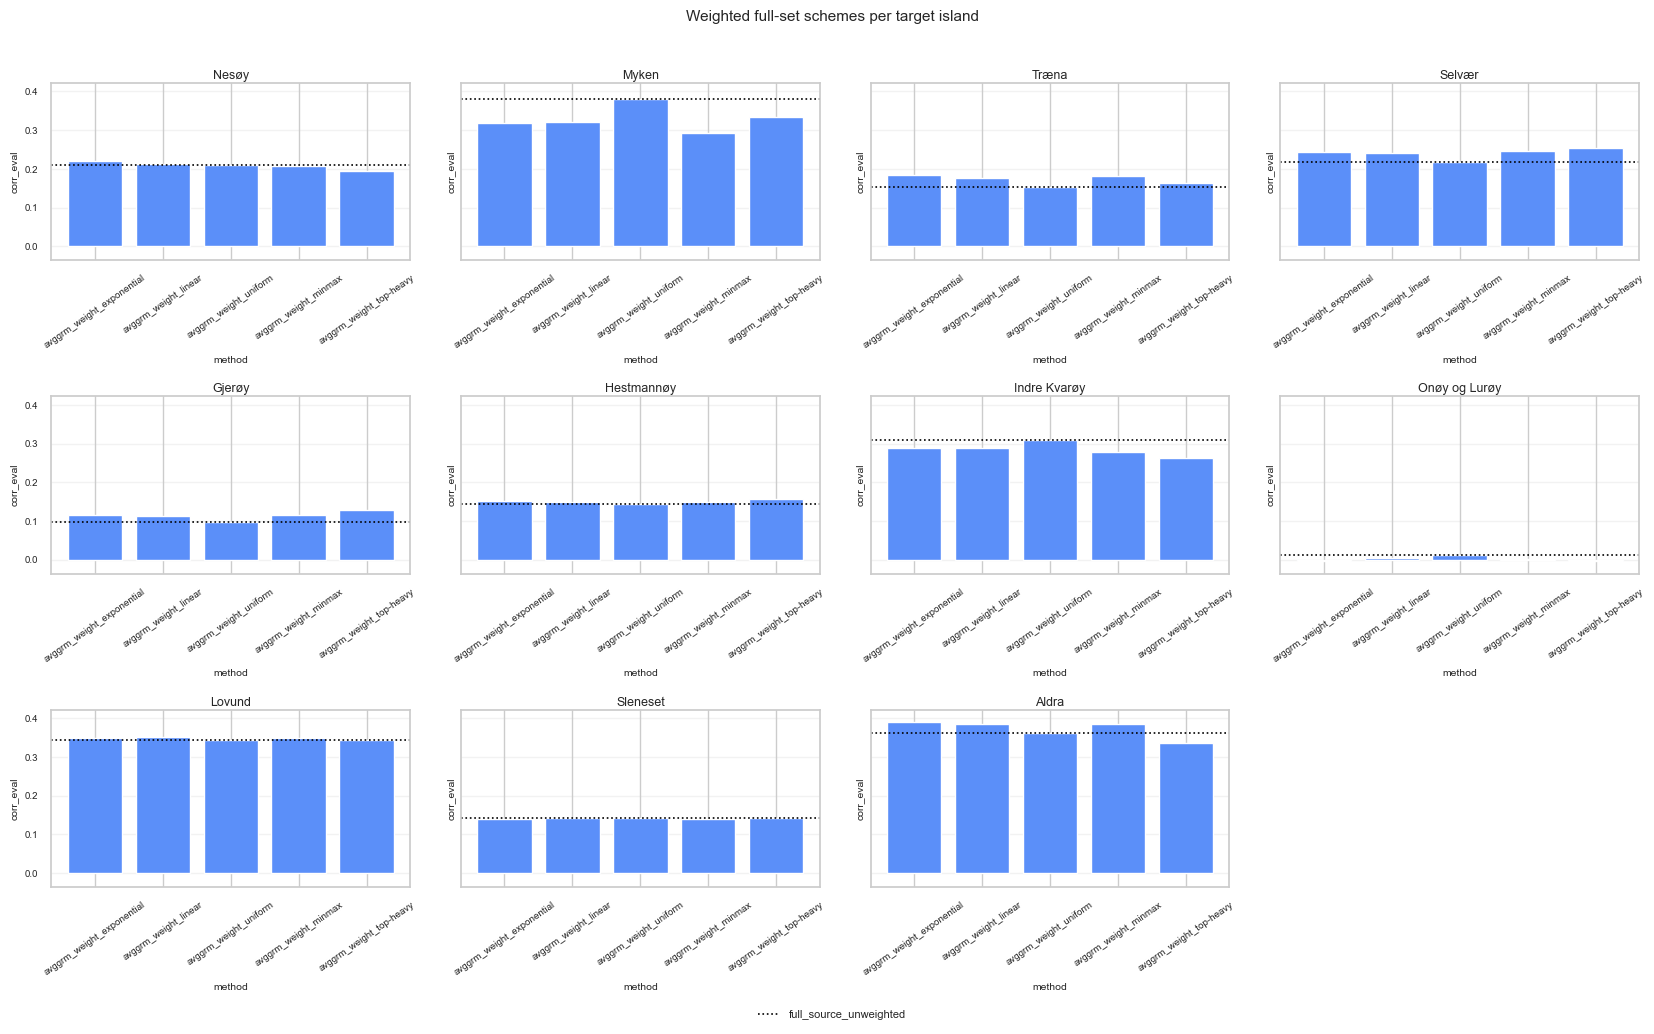

,method,corr_mean,mse_mean
0,avggrm_weight_exponential,0.217983,1.282360
1,avggrm_weight_linear,0.216936,1.282930
4,avggrm_weight_uniform,0.216146,1.285638
2,avggrm_weight_minmax,0.213388,1.284035
3,avggrm_weight_top-heavy,0.210542,1.284030


In [66]:
# --- Per-target performance heatmap (avggrm_topk, ranked subset) ---
if n_tgt > 1:
    hm_data = (
        results[(results['analysis'] == 'ranked_subset') & (results['method'] == 'avggrm_topk')]
        .groupby(['target_island_name', 'n_individuals'], as_index=False)
        .agg(corr_mean=('corr_eval', 'mean'))
    )
    pivot = hm_data.pivot(index='target_island_name', columns='n_individuals', values='corr_mean')
    pivot.columns.name = 'n_individuals'
    pivot = pivot.sort_index()
    fig_w = max(10, len(pivot.columns) * 0.75)
    fig_h = max(4, len(pivot) * 0.45 + 1.5)
    plt.figure(figsize=(fig_w, fig_h))
    sns.heatmap(
        pivot, annot=True, fmt='.3f', cmap='RdYlGn',
        center=float(pivot.stack().median()),
        linewidths=0.3, cbar_kws={'shrink': 0.7},
        mask=pivot.isna(),
    )
    plt.title('avggrm_topk: mean corr_eval per target island × training size')
    plt.xlabel('Training size (n_individuals)')
    plt.ylabel('Target island')
    plt.tight_layout()
    plt.show()

# --- Weighted full-set scheme comparison ---
weighted = results[results['analysis'] == 'weighted_full'].copy()
weighted_mean = (
    weighted.groupby('method', as_index=False)
    .agg(corr_mean=('corr_eval', 'mean'), mse_mean=('mse_adj', 'mean'))
    .sort_values('corr_mean', ascending=False)
)

if len(weighted_mean):
    plt.figure(figsize=(10, 4))
    sns.barplot(data=weighted_mean, x='method', y='corr_mean', color='#5B8FF9')
    plt.xticks(rotation=35, ha='right')
    plt.title(f'Weighted full-set schemes (mean corr_eval, {tgt_label})')
    plt.tight_layout()
    plt.show()

# --- Weighted full-set schemes per target island ---
if len(weighted_mean) and n_tgt > 1:
    weighted_per_tgt = (
        weighted.groupby(['target_island_name', 'method'], as_index=False)
        .agg(corr_mean=('corr_eval', 'mean'))
    )
    full_per_tgt = (
        results[results['method'] == 'full_source_unweighted']
        .groupby('target_island_name', as_index=False)
        .agg(full_corr=('corr_eval', 'mean'))
    )
    island_order = target_info['target_island_name'].tolist()
    method_order = weighted_mean['method'].tolist()

    n_panels = len(island_order)
    n_cols_g = min(4, n_panels)
    n_rows_g = int(math.ceil(n_panels / n_cols_g))
    panel_w, panel_h = 4.2, 3.3
    fig, axes = plt.subplots(
        n_rows_g, n_cols_g,
        figsize=(n_cols_g * panel_w, n_rows_g * panel_h),
        squeeze=False,
        sharey=True,
    )

    global_min = min(weighted_per_tgt['corr_mean'].min(), full_per_tgt['full_corr'].min())
    global_max = max(weighted_per_tgt['corr_mean'].max(), full_per_tgt['full_corr'].max())
    pad = max(0.01, 0.08 * (global_max - global_min if global_max > global_min else 1.0))

    for ax, island_name in zip(axes.flatten(), island_order):
        sub = weighted_per_tgt[weighted_per_tgt['target_island_name'] == island_name].copy()
        sub['method'] = pd.Categorical(sub['method'], categories=method_order, ordered=True)
        sub = sub.sort_values('method')

        ax.bar(sub['method'].astype(str), sub['corr_mean'], color='#5B8FF9')

        fc_row = full_per_tgt[full_per_tgt['target_island_name'] == island_name]
        if not fc_row.empty:
            ax.axhline(
                float(fc_row['full_corr'].iloc[0]),
                color='black', linestyle=':', linewidth=1.2, label='full_source_unweighted'
            )

        ax.set_title(island_name, fontsize=9, pad=3)
        ax.set_xlabel('method', fontsize=7.5)
        ax.set_ylabel('corr_eval', fontsize=7.5)
        ax.tick_params(axis='x', rotation=35, labelsize=7)
        ax.tick_params(axis='y', labelsize=7)
        ax.grid(axis='y', alpha=0.25)
        ax.set_ylim(global_min - pad, global_max + pad)

    for ax in axes.flatten()[n_panels:]:
        ax.set_visible(False)

    handles, labels = axes.flatten()[0].get_legend_handles_labels()
    if handles:
        fig.legend(
            handles, labels, loc='lower center', ncol=len(handles),
            bbox_to_anchor=(0.5, -0.02), fontsize=8, frameon=False
        )
    fig.suptitle('Weighted full-set schemes per target island', y=1.01, fontsize=11)
    fig.tight_layout()
    plt.show()

weighted_mean

In [67]:
if len(selected_df):
    print('Top ranked individuals example:')
    display(selected_df.sort_values(['target_island', 'repeat', 'n_train_size', 'rank']).head(20))

if len(weights_df):
    print('Weight distribution example:')
    display(weights_df[['method', 'weight']].groupby('method').describe().round(4))

Top ranked individuals example:


,trait,target_island,target_island_name,repeat,repeat_seed,n_train_size,method,ringnr,ringnumber,source_island,source_island_name,rank,avg_grm
0,body_mass,0,Nesøy,0,885682700,50,avggrm_topk,8L19992,8L19992,4,Gjerøy,1,0.081158
1,body_mass,0,Nesøy,0,885682700,50,avggrm_topk,8N73533,8N73533,5,Hestmannøy,2,0.079277
2,body_mass,0,Nesøy,0,885682700,50,avggrm_topk,8M71531,8M71531,4,Gjerøy,3,0.063899
3,body_mass,0,Nesøy,0,885682700,50,avggrm_topk,8N27886,8N27886,2,Træna,4,0.063088
4,body_mass,0,Nesøy,0,885682700,50,avggrm_topk,8M71310,8M71310,5,Hestmannøy,5,0.062304
5,body_mass,0,Nesøy,0,885682700,50,avggrm_topk,8M31634,8M31634,4,Gjerøy,6,0.061554
6,body_mass,0,Nesøy,0,885682700,50,avggrm_topk,8M31317,8M31317,4,Gjerøy,7,0.060944
7,body_mass,0,Nesøy,0,885682700,50,avggrm_topk,8N06727,8N06727,4,Gjerøy,8,0.060262
8,body_mass,0,Nesøy,0,885682700,50,avggrm_topk,8M31532,8M31532,5,Hestmannøy,9,0.059976
9,body_mass,0,Nesøy,0,885682700,50,avggrm_topk,8L89663,8L89663,4,Gjerøy,10,0.059526


Weight distribution example:


weight                                       \
                             count mean     std     min     25%     50%   
method                                                                    
avggrm_weight_exponential  34450.0  1.0  0.2944  0.4827  0.8704  0.9446   
avggrm_weight_linear       34450.0  1.0  0.2861  0.3226  0.8441  0.9489   
avggrm_weight_minmax       34450.0  1.0  0.4245  0.1250  0.7667  0.9236   
avggrm_weight_top-heavy    34450.0  1.0  0.5715  0.7140  0.7140  0.7141   
avggrm_weight_uniform      34450.0  1.0  0.0000  1.0000  1.0000  1.0000   

                                           
                              75%     max  
method                                     
avggrm_weight_exponential  1.0310  5.4605  
avggrm_weight_linear       1.0721  3.7832  
avggrm_weight_minmax       1.1082  5.4770  
avggrm_weight_top-heavy    0.7142  2.1427  
avggrm_weight_uniform      1.0000  1.0000

## Island Contribution Diagnostics (Like PEVmean)
Expected vs actual contribution by source island for `avggrm_topk`, plus the fraction of available birds selected from each island.

In [68]:
# Select which target island to use in the provenance diagnostics below.
# Set either selected_target_island (integer code) or selected_target_island_name (string).
selected_target_island = 9
selected_target_island_name = None

if selected_target_island is None and selected_target_island_name is None:
    selected_target_island = int(target_info['target_island'].iloc[0])

selected_target_row = target_info[target_info['target_island'] == selected_target_island].copy()
if selected_target_row.empty and selected_target_island_name is not None:
    selected_target_row = target_info[
        target_info['target_island_name'].astype(str) == str(selected_target_island_name)
    ].copy()
if selected_target_row.empty:
    raise ValueError(
        'Selected target island not found. Set selected_target_island or '
        'selected_target_island_name to one of the values printed above.'
    )

selected_target_island = int(selected_target_row['target_island'].iloc[0])
selected_target_island_name = str(selected_target_row['target_island_name'].iloc[0])
print(f"Selected provenance island: {selected_target_island}  {selected_target_island_name}")

Selected provenance island: 9  Sleneset


Computing island provenance for target island: 9  Sleneset


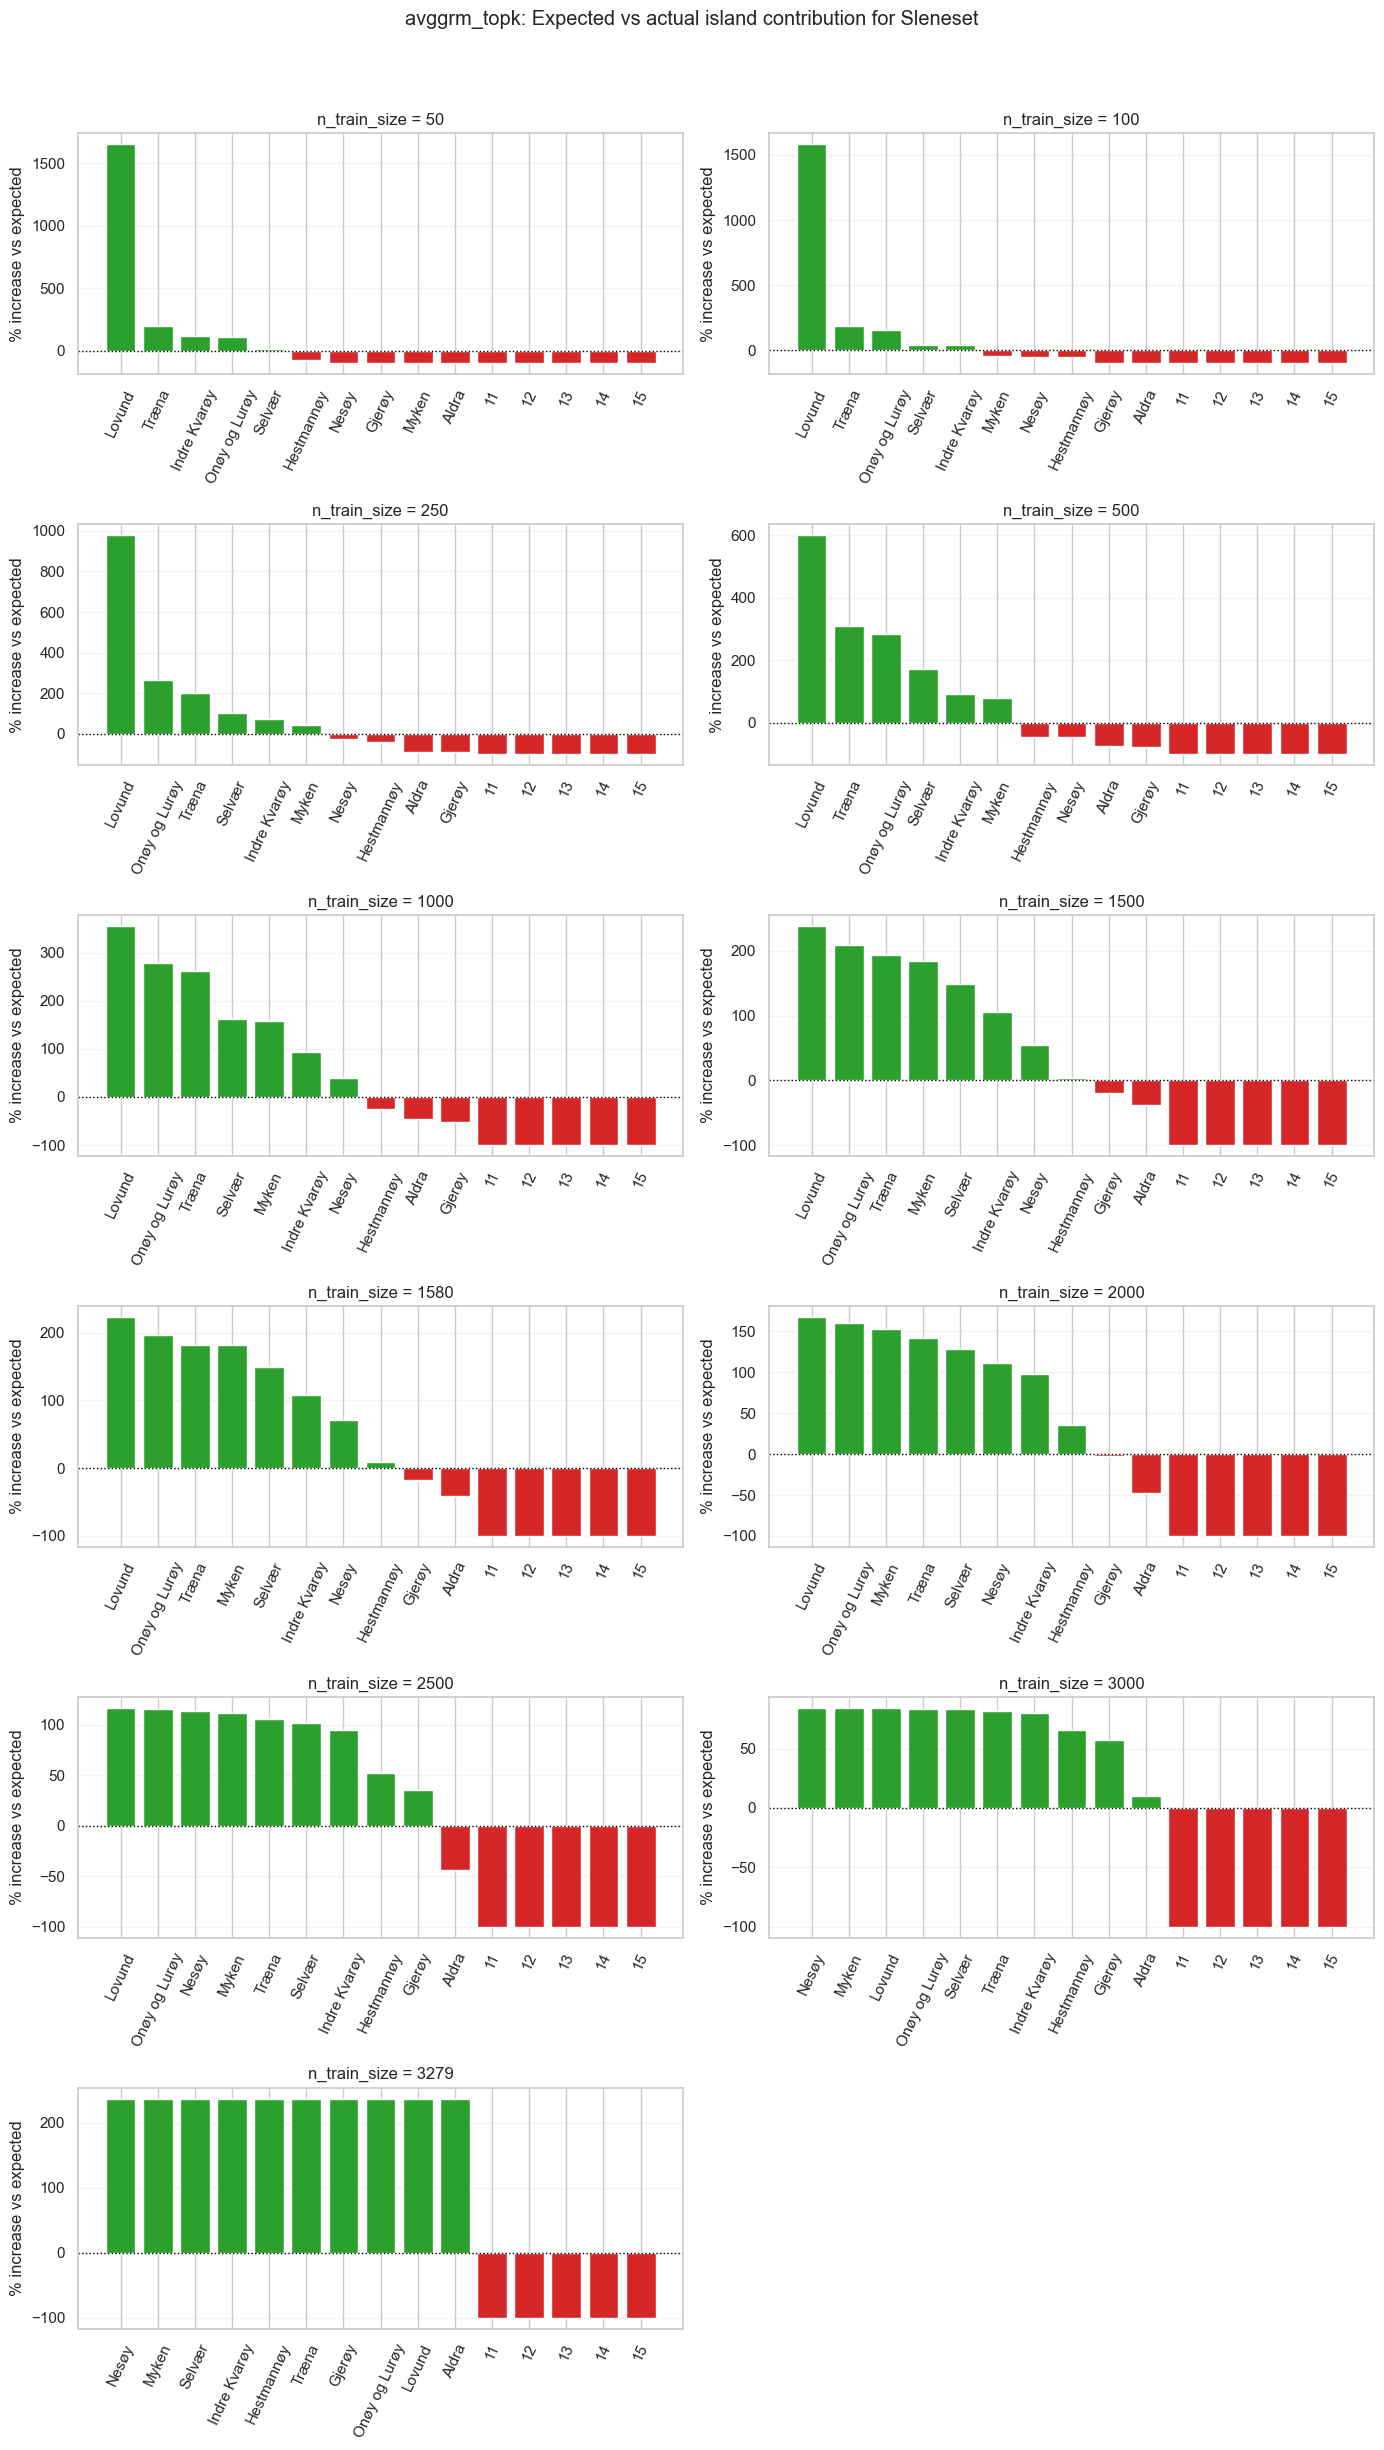

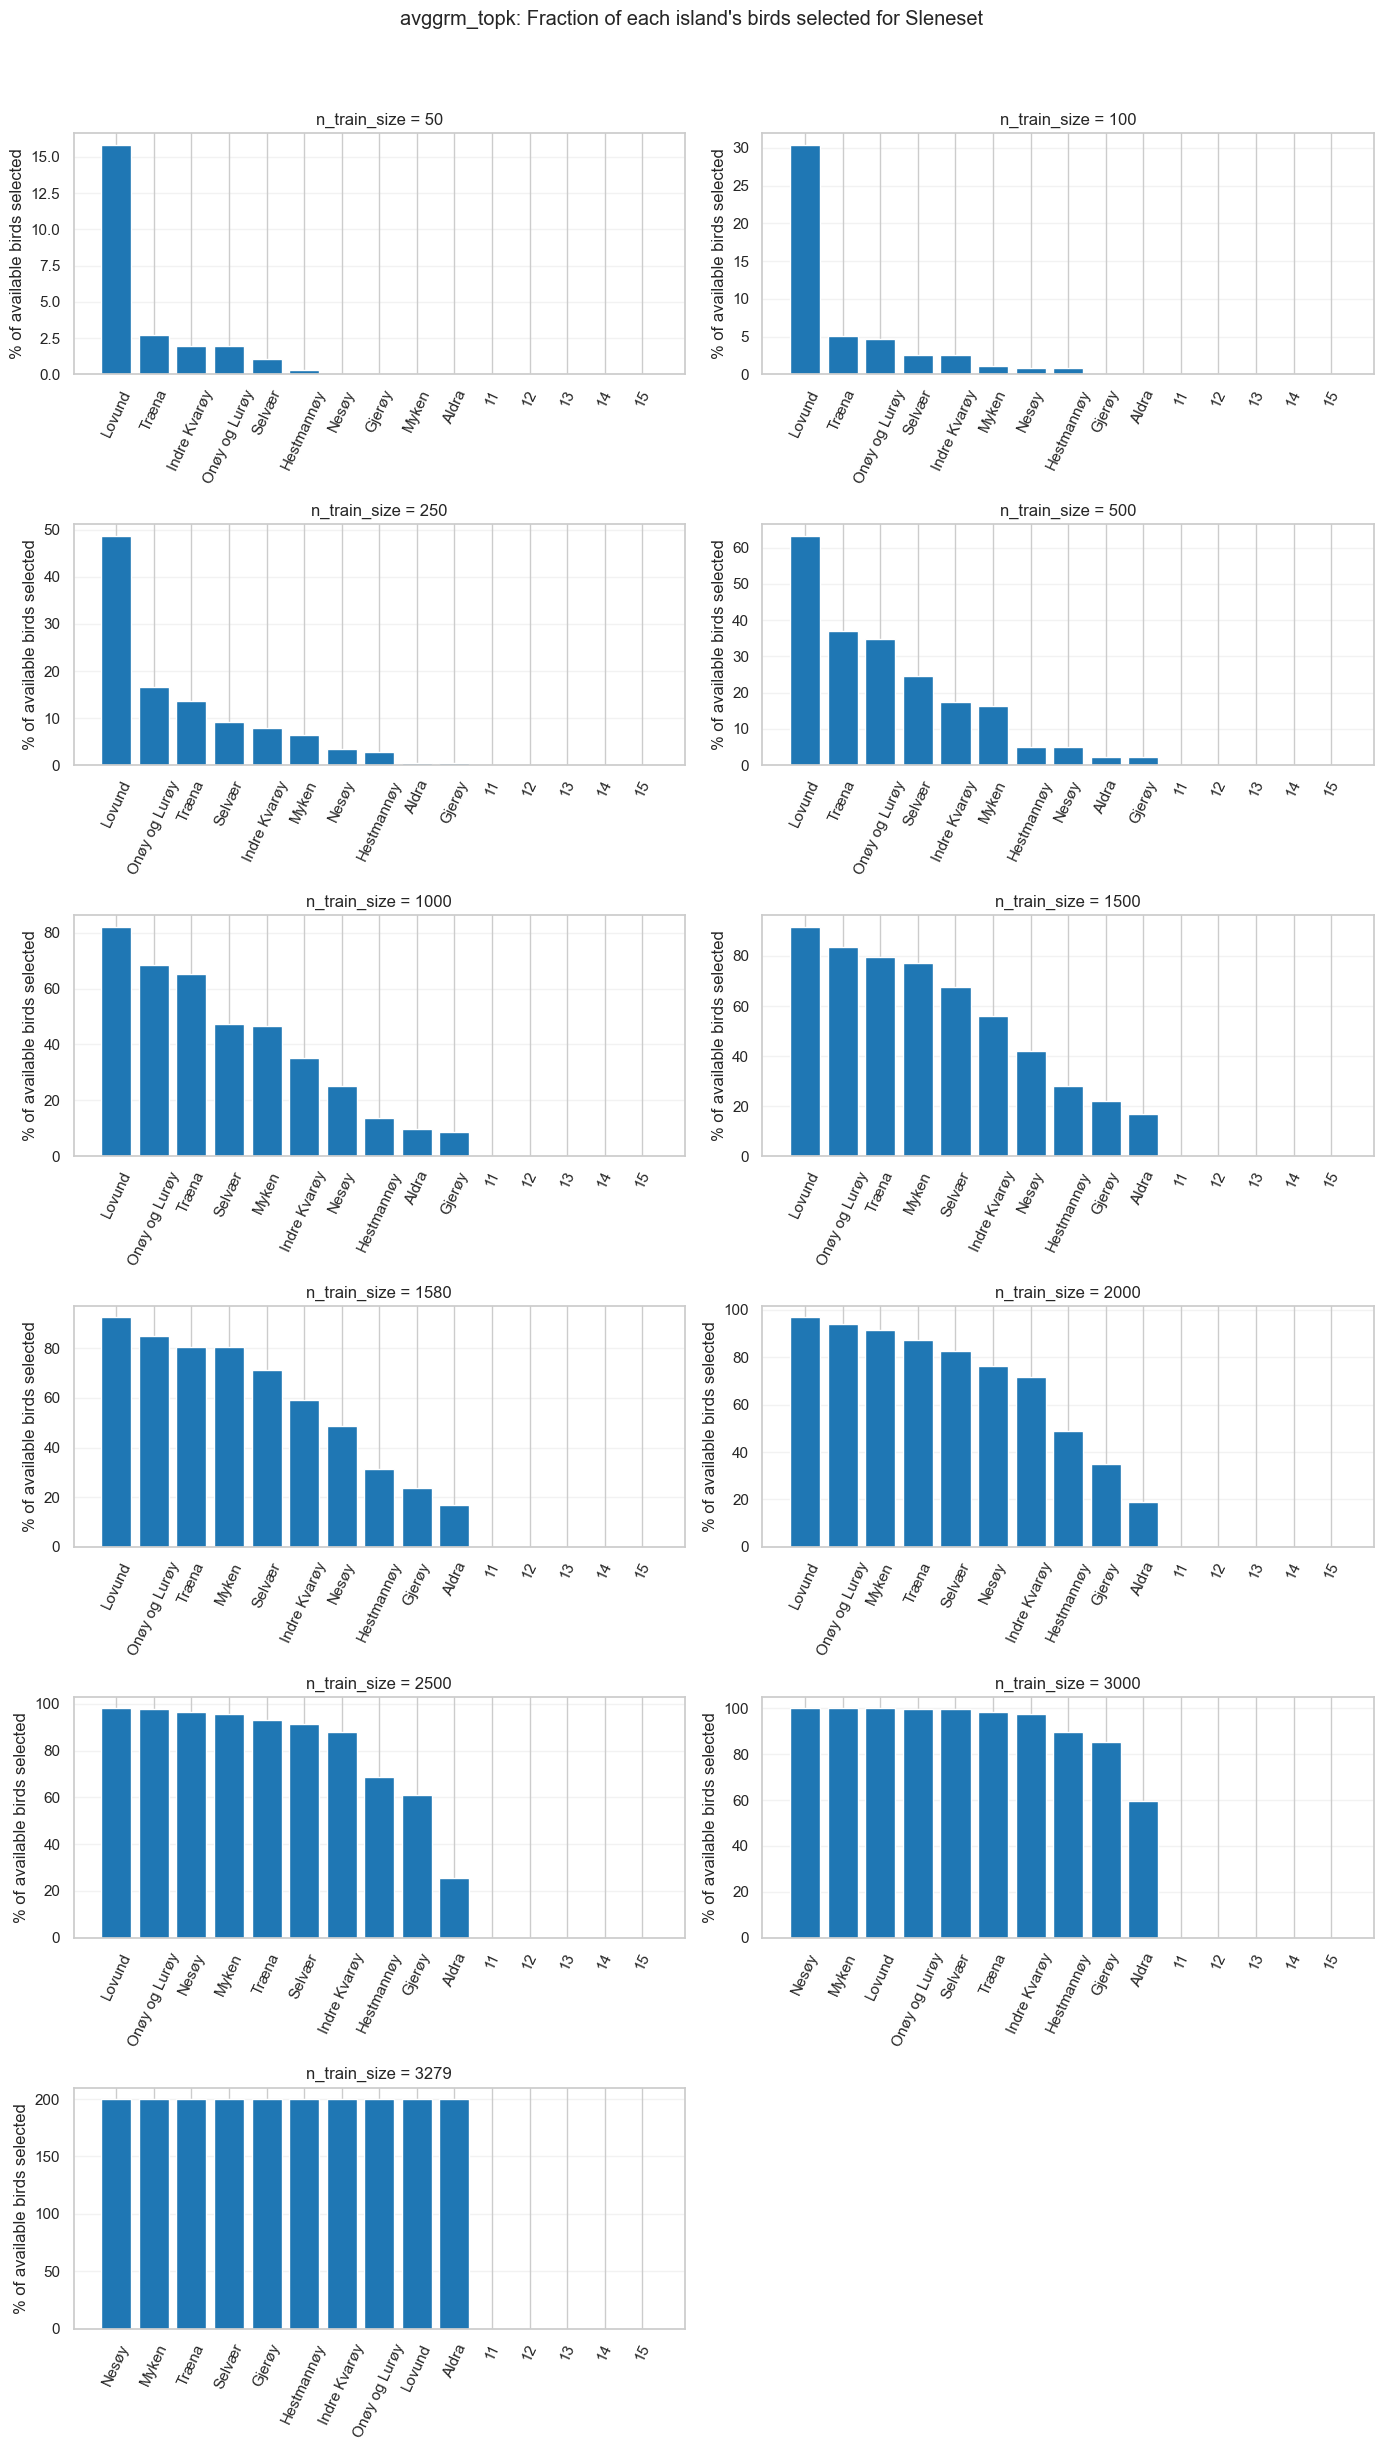

,n_train_size,source_name,pool_count,expected_count,actual_count,fraction_increase_vs_expected,selection_fraction_of_available
8,50,Lovund,158,1.428313,25.0,16.503165,0.158228
2,50,Træna,292,2.639667,8.0,2.030685,0.027397
6,50,Indre Kvarøy,356,3.218225,7.0,1.175112,0.019663
7,50,Onøy og Lurøy,259,2.341349,5.0,1.135521,0.019305
3,50,Selvær,194,1.753752,2.0,0.140412,0.010309
23,100,Lovund,158,2.856626,48.0,15.803038,0.303797
17,100,Træna,292,5.279335,15.0,1.841267,0.051370
22,100,Onøy og Lurøy,259,4.682698,12.0,1.562625,0.046332
18,100,Selvær,194,3.507503,5.0,0.425515,0.025773
21,100,Indre Kvarøy,356,6.436449,9.0,0.398287,0.025281


In [69]:
# Expected vs actual island contribution for one selected target island
import sys
import json
import math
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data import load_data

if selected_df.empty:
    raise ValueError('selected_df is empty. Run the experiment and re-run loading cells first.')

config_path = ROOT / 'config' / 'avggrm_rank_weight_config.json'
with open(config_path, 'r') as f:
    cfg = json.load(f)

trait_name = str(results['trait'].iloc[0]) if ('trait' in results.columns and len(results)) else None
trait_cfg = None
for t in cfg.get('traits', []):
    if trait_name is None or str(t.get('name')) == trait_name:
        trait_cfg = t
        break
if trait_cfg is None:
    trait_cfg = cfg.get('traits', [{}])[0]

paths = dict(cfg['paths'])
if 'npz' in trait_cfg:
    paths['npz'] = trait_cfg['npz']
for k, v in list(paths.items()):
    if isinstance(v, str):
        p = Path(v)
        if not p.is_absolute():
            p = (ROOT / p).resolve()
        paths[k] = str(p)

X, y, ids, GRM_df, locality, code_to_label, y_eval = load_data(
    paths=paths,
    target_column=trait_cfg.get('target_column', cfg.get('target_column', 'y_adjusted')),
    standardize_features=trait_cfg.get('standardize_features', cfg.get('standardize_features', True)),
    return_locality=True,
    min_count=int(trait_cfg.get('min_count', cfg.get('min_count', 20))),
    return_eval=True,
    eval_target_column=trait_cfg.get('eval_target_column', cfg.get('eval_target_column', 'y_mean')),
)

sel = selected_df[selected_df['method'] == 'avggrm_topk'].copy()
if sel.empty:
    raise ValueError('No avggrm_topk rows in selected_df.')

sel = sel[sel['target_island'] == selected_target_island].copy()
if sel.empty:
    raise ValueError(
        f'No avggrm_topk rows found for selected target island '
        f'{selected_target_island} ({selected_target_island_name}).'
    )
print(f'Computing island provenance for target island: {selected_target_island}  {selected_target_island_name}')

target_code = int(selected_target_island)
source_locality = locality[locality != target_code]

pool_df = (
    pd.Series(source_locality)
    .value_counts()
    .sort_index()
    .rename_axis('source_code')
    .reset_index(name='pool_count')
)
name_map = (
    sel[['source_island', 'source_island_name']]
    .drop_duplicates()
    .rename(columns={'source_island': 'source_code', 'source_island_name': 'source_name'})
)
pool_df = pool_df.merge(name_map, on='source_code', how='left')
pool_df['source_name'] = pool_df['source_name'].fillna(pool_df['source_code'].astype(str))
pool_df['pool_frac'] = pool_df['pool_count'] / pool_df['pool_count'].sum()

per_repeat_counts = (
    sel.groupby(['repeat', 'n_train_size', 'source_island'], as_index=False)
    .size()
    .rename(columns={'size': 'n_selected'})
)
all_repeats = sorted(sel['repeat'].unique().tolist())
all_sizes = sorted(sel['n_train_size'].unique().tolist())
all_islands = sorted(pool_df['source_code'].unique().tolist())
full_index = pd.MultiIndex.from_product(
    [all_repeats, all_sizes, all_islands],
    names=['repeat', 'n_train_size', 'source_island']
 )
counts = (
    per_repeat_counts
    .set_index(['repeat', 'n_train_size', 'source_island'])
    .reindex(full_index, fill_value=0)
    .reset_index()
)
counts = counts.merge(name_map, left_on='source_island', right_on='source_code', how='left')
counts['source_name'] = counts['source_name'].fillna(counts['source_island'].astype(str))
counts['frac_selected'] = counts['n_selected'] / counts['n_train_size']

actual_df = (
    counts.groupby(['n_train_size', 'source_island', 'source_name'], as_index=False)
    .agg(
        actual_count=('n_selected', 'mean'),
        actual_frac_in_train=('frac_selected', 'mean'),
    )
)
exp_act = actual_df.merge(
    pool_df[['source_code', 'pool_count', 'pool_frac']],
    left_on='source_island',
    right_on='source_code',
    how='left'
)
exp_act['expected_count'] = exp_act['n_train_size'] * exp_act['pool_frac']
exp_act['selection_fraction_of_available'] = exp_act['actual_count'] / exp_act['pool_count']
exp_act['fraction_increase_vs_expected'] = np.where(
    exp_act['expected_count'] > 0,
    (exp_act['actual_count'] - exp_act['expected_count']) / exp_act['expected_count'],
    np.nan,
)

sizes = sorted(exp_act['n_train_size'].unique().tolist())
n_cols = 2
n_rows = int(math.ceil(len(sizes) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.0 * n_rows), squeeze=False)
for ax, n_train in zip(axes.flatten(), sizes):
    sub = exp_act[exp_act['n_train_size'] == n_train].sort_values('fraction_increase_vs_expected', ascending=False)
    colors = np.where(sub['fraction_increase_vs_expected'] >= 0, '#2ca02c', '#d62728')
    ax.bar(sub['source_name'], sub['fraction_increase_vs_expected'] * 100.0, color=colors)
    ax.axhline(0.0, color='black', linewidth=1, linestyle=':')
    ax.set_title(f'n_train_size = {n_train}')
    ax.set_ylabel('% increase vs expected')
    ax.tick_params(axis='x', rotation=65)
    ax.grid(axis='y', alpha=0.25)
for ax in axes.flatten()[len(sizes):]:
    ax.set_visible(False)
fig.suptitle(
    f'avggrm_topk: Expected vs actual island contribution for {selected_target_island_name}',
    y=1.02,
 )
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.0 * n_rows), squeeze=False)
for ax, n_train in zip(axes.flatten(), sizes):
    sub = exp_act[exp_act['n_train_size'] == n_train].sort_values('selection_fraction_of_available', ascending=False)
    ax.bar(sub['source_name'], sub['selection_fraction_of_available'] * 100.0, color='#1f77b4')
    ax.set_title(f'n_train_size = {n_train}')
    ax.set_ylabel('% of available birds selected')
    ax.tick_params(axis='x', rotation=65)
    ax.grid(axis='y', alpha=0.25)
for ax in axes.flatten()[len(sizes):]:
    ax.set_visible(False)
fig.suptitle(
    f"avggrm_topk: Fraction of each island's birds selected for {selected_target_island_name}",
    y=1.02,
 )
fig.tight_layout()
plt.show()

top_lift = (
    exp_act
    .sort_values(['n_train_size', 'fraction_increase_vs_expected'], ascending=[True, False])
    .groupby('n_train_size', as_index=False)
    .head(5)
    [['n_train_size', 'source_name', 'pool_count', 'expected_count', 'actual_count',
      'fraction_increase_vs_expected', 'selection_fraction_of_available']]
)
top_lift

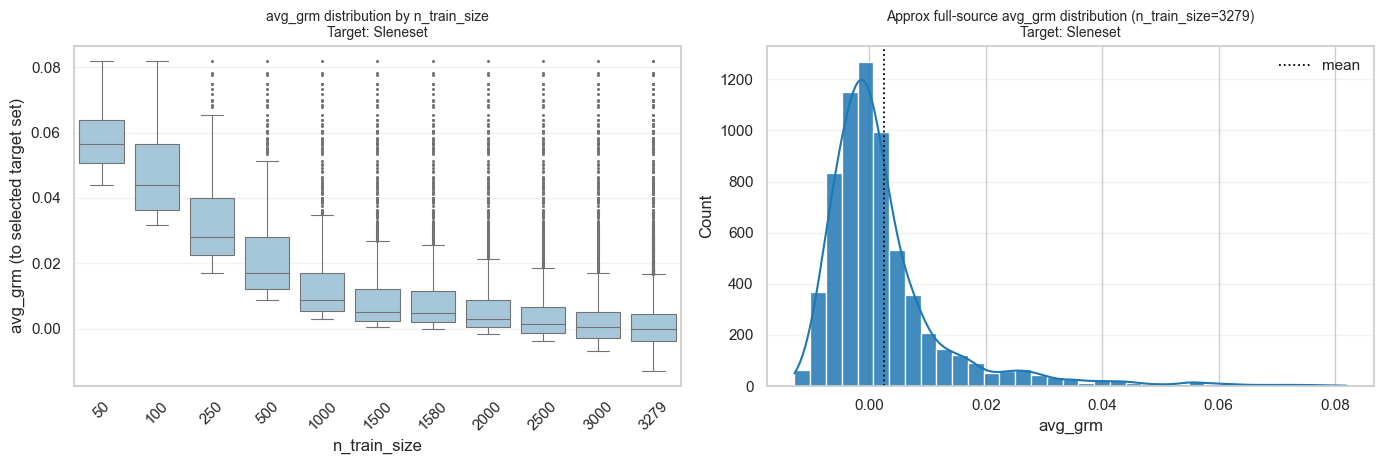

,approx_full_distribution_stats
count,6558.000000
mean,0.002477
std,0.011190
min,-0.012872
25%,-0.003790
50%,-0.000289
75%,0.004445
max,0.081918


In [70]:
# Distribution of avg_grm values for the selected target island
if 'selected_target_island' not in globals():
    raise ValueError('Run the selector cell above first.')

# Reuse sel from the provenance cell if available; otherwise rebuild from selected_df.
if 'sel' in globals() and len(sel):
    sel_dist = sel.copy()
else:
    sel_dist = selected_df[
        (selected_df['method'] == 'avggrm_topk')
        & (selected_df['target_island'] == selected_target_island)
    ].copy()

if sel_dist.empty:
    raise ValueError(
        f'No avggrm_topk selected rows for target island '
        f'{selected_target_island} ({selected_target_island_name}).'
    )
if 'avg_grm' not in sel_dist.columns:
    raise ValueError('Column avg_grm not found in selected_df.')

dist_df = sel_dist[['n_train_size', 'avg_grm']].dropna().copy()
if dist_df.empty:
    raise ValueError('No non-missing avg_grm values available for plotting.')

sizes_present = sorted(dist_df['n_train_size'].unique().tolist())
approx_n = 4500 if 4500 in sizes_present else max(sizes_present)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

# Left panel: distribution across training sizes
sns.boxplot(
    data=dist_df,
    x='n_train_size',
    y='avg_grm',
    ax=axes[0],
    color='#9ecae1',
    fliersize=1.2,
    linewidth=0.8,
 )
axes[0].set_title(
    f'avg_grm distribution by n_train_size\nTarget: {selected_target_island_name}',
    fontsize=10,
 )
axes[0].set_xlabel('n_train_size')
axes[0].set_ylabel('avg_grm (to selected target set)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.25)

# Right panel: approx full-source distribution
approx_df = dist_df[dist_df['n_train_size'] == approx_n].copy()
sns.histplot(
    approx_df['avg_grm'],
    bins=35,
    kde=True,
    ax=axes[1],
    color='#1f77b4',
    edgecolor='white',
    alpha=0.85,
 )
axes[1].axvline(approx_df['avg_grm'].mean(), color='black', linestyle=':', linewidth=1.3, label='mean')
axes[1].set_title(
    f'Approx full-source avg_grm distribution (n_train_size={approx_n})\nTarget: {selected_target_island_name}',
    fontsize=10,
 )
axes[1].set_xlabel('avg_grm')
axes[1].set_ylabel('Count')
axes[1].grid(axis='y', alpha=0.25)
axes[1].legend(frameon=False)

fig.tight_layout()
plt.show()

approx_df['avg_grm'].describe().to_frame('approx_full_distribution_stats')

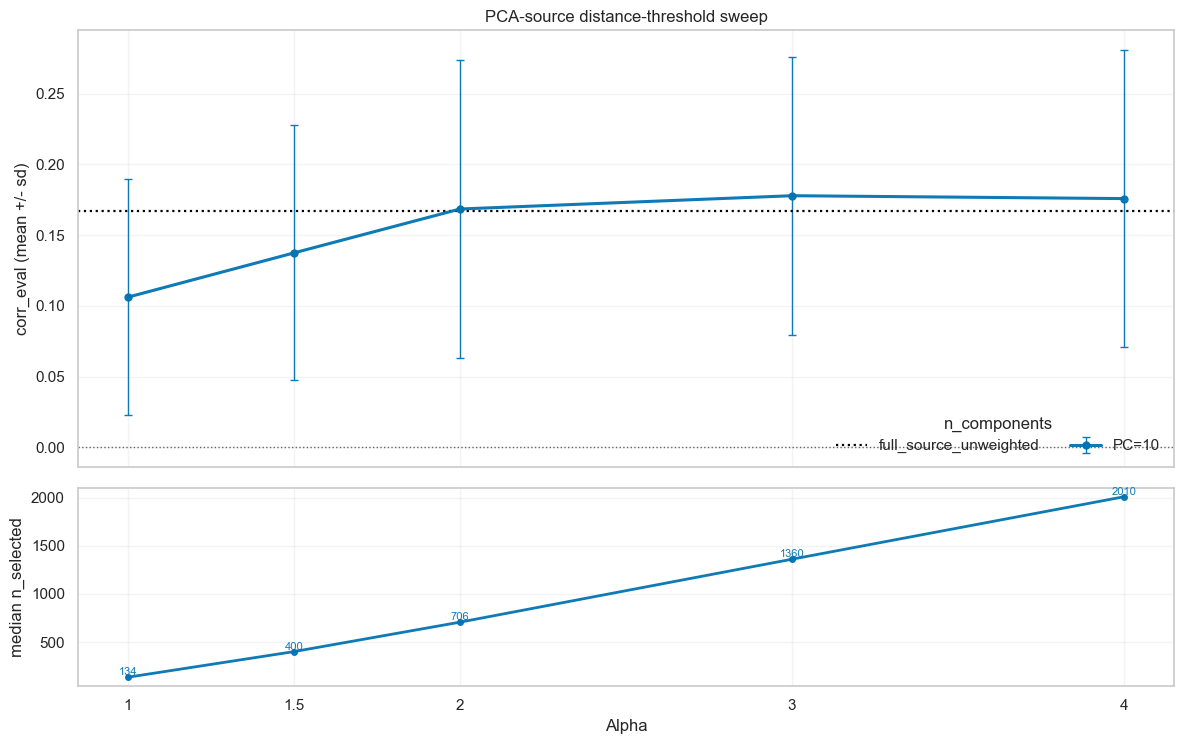

Median n_selected by alpha and PC:


,PC=10
alpha,
1.0,134.0
1.5,400.0
2.0,706.0
3.0,1360.0
4.0,2010.0


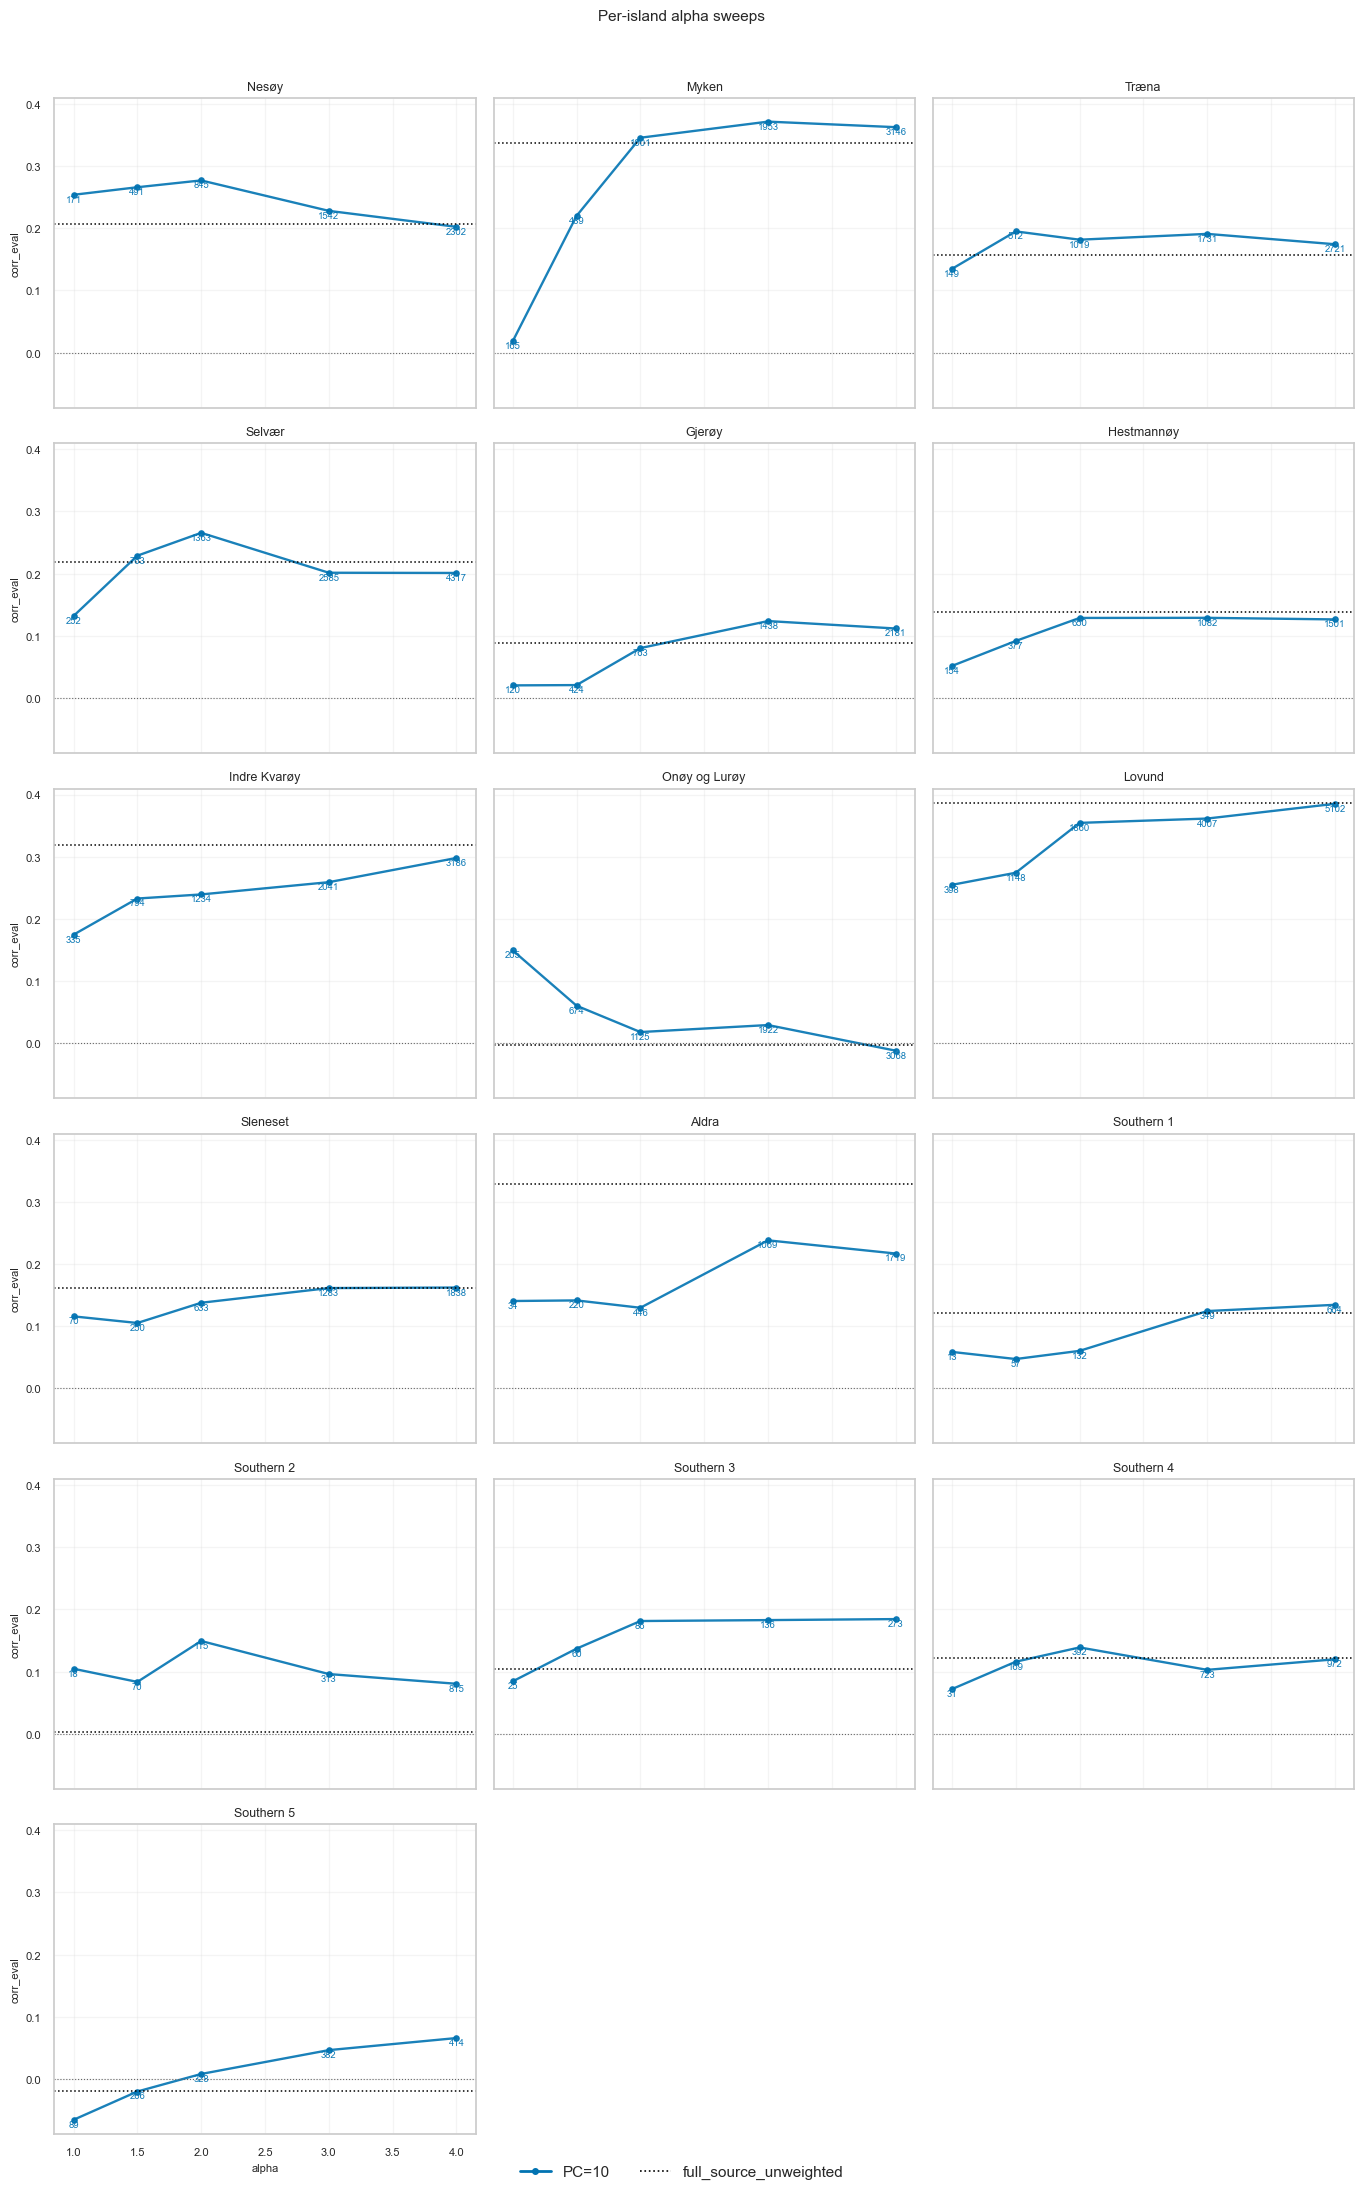

Alpha-sweep plotted: 80 rows, 16 islands, 1 PC settings


In [71]:
# Alpha-sweep distance-threshold analysis (readable figure set)

if "alpha" not in pca_source_results.columns:
    print("Alpha column not found in pca_source_results.")
else:
    alpha_results = pca_source_results[
        (pca_source_results["analysis"] == "distance_threshold")
        & (pca_source_results["alpha"].notna())
    ].copy()

    if alpha_results.empty:
        print("No distance-threshold results found in results.")
    else:
        # Normalize numeric columns
        alpha_results["alpha"] = pd.to_numeric(alpha_results["alpha"], errors="coerce")
        alpha_results["n_components"] = pd.to_numeric(alpha_results["n_components"], errors="coerce")
        alpha_results["corr_eval"] = pd.to_numeric(alpha_results["corr_eval"], errors="coerce")
        alpha_results["n_individuals"] = pd.to_numeric(alpha_results["n_individuals"], errors="coerce")
        alpha_results = alpha_results.dropna(subset=["alpha", "n_components", "corr_eval", "n_individuals"]).copy()
        alpha_results["n_components"] = alpha_results["n_components"].astype(int)

        if alpha_results.empty:
            print("No usable alpha rows after numeric cleanup.")
        else:
            alpha_values = sorted(alpha_results["alpha"].unique().tolist())
            pc_values = sorted(alpha_results["n_components"].unique().tolist())

            # Full-source baseline (global + per island)
            full_base = pca_source_results[pca_source_results["method"] == "full_source_unweighted"].copy()
            full_base["corr_eval"] = pd.to_numeric(full_base["corr_eval"], errors="coerce")
            full_base = full_base.dropna(subset=["corr_eval"])
            full_global_corr = float(full_base["corr_eval"].mean()) if len(full_base) else np.nan
            full_by_island = {}
            if len(full_base) and "target_island" in full_base.columns:
                full_by_island = (
                    full_base.groupby("target_island", as_index=True)["corr_eval"].mean().to_dict()
                )

            global_agg = (
                alpha_results.groupby(["n_components", "alpha"], as_index=False)
                .agg(
                    corr_mean=("corr_eval", "mean"),
                    corr_sd=("corr_eval", "std"),
                    n_selected_mean=("n_individuals", "mean"),
                    n_selected_median=("n_individuals", "median"),
                    n_rows=("corr_eval", "size"),
                )
                .sort_values(["n_components", "alpha"])
            )
            global_agg["corr_sd"] = global_agg["corr_sd"].fillna(0.0)

            # Colorblind-friendly palette
            palette = sns.color_palette("colorblind", n_colors=len(pc_values))
            pc_color = {pc: palette[i] for i, pc in enumerate(pc_values)}
            pc_rank = {pc: i for i, pc in enumerate(pc_values)}

            # Two aligned panels: performance + selected size
            fig, axes = plt.subplots(
                2,
                1,
                figsize=(12.0, 7.6),
                sharex=True,
                gridspec_kw={"height_ratios": [2.2, 1.0]},
            )
            ax_top, ax_bottom = axes

            n_min = float(global_agg["n_selected_median"].min())
            n_max = float(global_agg["n_selected_median"].max())
            n_span = max(1.0, n_max - n_min)
            text_step = max(14.0, 0.03 * n_span)

            for pc in pc_values:
                sub = global_agg[global_agg["n_components"] == pc]
                if sub.empty:
                    continue

                # Top: corr vs alpha with SD bars
                ax_top.errorbar(
                    sub["alpha"],
                    sub["corr_mean"],
                    yerr=sub["corr_sd"],
                    marker="o",
                    linestyle="-",
                    linewidth=2.2,
                    elinewidth=1.0,
                    capsize=3,
                    markersize=5,
                    color=pc_color[pc],
                    alpha=0.95,
                    label=f"PC={pc}",
                )

                # Bottom: selected set size vs alpha
                ax_bottom.plot(
                    sub["alpha"],
                    sub["n_selected_median"],
                    marker="o",
                    linestyle="-",
                    linewidth=2.0,
                    markersize=4,
                    color=pc_color[pc],
                    alpha=0.95,
                )

                # Colored point labels with n_selected values
                rank_i = pc_rank[pc]
                for x, y in zip(sub["alpha"], sub["n_selected_median"]):
                    ax_bottom.text(
                        float(x),
                        float(y) + (rank_i * text_step),
                        f"{int(round(float(y)))}",
                        color=pc_color[pc],
                        fontsize=8,
                        ha="center",
                        va="bottom",
                        alpha=0.95,
                    )

            # Full-source horizontal reference
            if np.isfinite(full_global_corr):
                ax_top.axhline(
                    full_global_corr,
                    color="black",
                    linestyle=":",
                    linewidth=1.6,
                    label="full_source_unweighted",
                )

            ax_top.axhline(0.0, color="#666666", linestyle=":", linewidth=1.0)
            ax_top.set_ylabel("corr_eval (mean +/- sd)")
            ax_top.set_title("PCA-source distance-threshold sweep")
            ax_top.grid(alpha=0.22)
            ax_top.legend(title="n_components", frameon=False, ncol=min(5, len(pc_values) + 1), loc="lower right")

            ax_bottom.set_xlabel("Alpha")
            ax_bottom.set_ylabel("median n_selected")
            ax_bottom.grid(alpha=0.22)

            # Force clean alpha ticks
            ax_bottom.set_xticks(alpha_values)
            ax_bottom.set_xticklabels([f"{a:g}" for a in alpha_values])

            fig.tight_layout()
            plt.savefig(out_dir / "alpha_sweep_clean.png", dpi=180, bbox_inches="tight")
            plt.show()

            # Compact table for exact values
            n_table = (
                global_agg.pivot(index="alpha", columns="n_components", values="n_selected_median")
                .sort_index()
                .round(0)
            )
            n_table.columns = [f"PC={int(c)}" for c in n_table.columns]
            print("Median n_selected by alpha and PC:")
            display(n_table)

            # Per-island panel (also shown when there is only one island)
            per_island = (
                alpha_results.groupby(
                    ["target_island", "target_island_name", "n_components", "alpha"],
                    as_index=False,
                )
                .agg(
                    corr_mean=("corr_eval", "mean"),
                    n_selected_median=("n_individuals", "median"),
                )
                .sort_values(["target_island", "n_components", "alpha"])
            )
            islands = (
                per_island[["target_island", "target_island_name"]]
                .drop_duplicates()
                .sort_values("target_island")
            )
            island_codes = islands["target_island"].tolist()

            if len(island_codes) > 0:
                n_panels = len(island_codes)
                n_cols = min(3, n_panels)
                n_rows = int(np.ceil(n_panels / n_cols))
                fig, axes = plt.subplots(
                    n_rows,
                    n_cols,
                    figsize=(n_cols * 4.6, n_rows * 3.6),
                    squeeze=False,
                    sharey=True,
                    sharex=True,
                )

                for i, target_code in enumerate(island_codes):
                    r = i // n_cols
                    c = i % n_cols
                    ax = axes[r, c]

                    sub_t = per_island[per_island["target_island"] == target_code]
                    island_name = sub_t["target_island_name"].iloc[0]

                    n_i_min = float(sub_t["n_selected_median"].min()) if len(sub_t) else 0.0
                    n_i_max = float(sub_t["n_selected_median"].max()) if len(sub_t) else 1.0
                    n_i_span = max(1.0, n_i_max - n_i_min)
                    text_step_i = max(8.0, 0.02 * n_i_span)

                    for pc in pc_values:
                        sub_pc = sub_t[sub_t["n_components"] == pc]
                        if sub_pc.empty:
                            continue
                        ax.plot(
                            sub_pc["alpha"],
                            sub_pc["corr_mean"],
                            marker="o",
                            linewidth=1.7,
                            markersize=3.8,
                            color=pc_color[pc],
                            alpha=0.9,
                        )

                        # Colored n labels near each alpha point
                        rank_i = pc_rank[pc]
                        for x, y, n_sel in zip(sub_pc["alpha"], sub_pc["corr_mean"], sub_pc["n_selected_median"]):
                            ax.text(
                                float(x),
                                float(y) - (rank_i * 0.012),
                                f"{int(round(float(n_sel)))}",
                                color=pc_color[pc],
                                fontsize=6.8,
                                ha="center",
                                va="top",
                                alpha=0.95,
                            )

                    # Full-source line per island
                    if target_code in full_by_island:
                        ax.axhline(
                            float(full_by_island[target_code]),
                            color="black",
                            linestyle=":",
                            linewidth=1.1,
                        )

                    ax.axhline(0.0, color="#666666", linestyle=":", linewidth=0.8)
                    ax.set_title(str(island_name), fontsize=9)
                    ax.grid(alpha=0.2)
                    ax.tick_params(labelsize=8)

                for j in range(n_panels, n_rows * n_cols):
                    r = j // n_cols
                    c = j % n_cols
                    axes[r, c].set_visible(False)

                for ax in axes[-1, :]:
                    if ax.get_visible():
                        ax.set_xlabel("alpha", fontsize=8)
                for ax in axes[:, 0]:
                    if ax.get_visible():
                        ax.set_ylabel("corr_eval", fontsize=8)

                handles = [
                    plt.Line2D([0], [0], color=pc_color[pc], lw=2, marker="o", ms=4, label=f"PC={pc}")
                    for pc in pc_values
                ]
                handles.append(
                    plt.Line2D([0], [0], color="black", lw=1.2, linestyle=":", label="full_source_unweighted")
                )
                fig.legend(handles=handles, loc="lower center", ncol=min(6, len(handles)), frameon=False)
                title = "Per-island alpha sweep" if n_panels == 1 else "Per-island alpha sweeps"
                fig.suptitle(title, y=1.01, fontsize=11)
                fig.tight_layout()
                plt.savefig(out_dir / "alpha_sweep_per_island_clean.png", dpi=170, bbox_inches="tight")
                plt.show()

            print(
                f"Alpha-sweep plotted: {len(alpha_results)} rows, "
                f"{len(island_codes)} islands, {len(pc_values)} PC settings"
            )